In [662]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import SimpleITK as sitk
import os
import pytomography
from pytomography.io.SPECT import dicom
from pytomography.projectors.SPECT import SPECTSystemMatrix
from pytomography.algorithms import OSEM
from pytomography.likelihoods import PoissonLogLikelihood
from pytomography.transforms.SPECT import SPECTAttenuationTransform, SPECTPSFTransform
from pytomography.utils import plot_utils, ESSEScatterModel, compute_EW_scatter
from pytomography.metadata.SPECT import SPECTObjectMeta, SPECTProjMeta
import json

In [663]:
current_dir = os.getcwd()
DATADIR = os.path.join(current_dir, '../../../src/pytomography/data/NIST_attenuation_data')
FILE_WATER = os.path.join(DATADIR, 'water.csv')

In [664]:
def plot_mhd(mhd_path, title="Mu-Map à 208 keV", pos=[None, None, None]):
    img = sitk.ReadImage(mhd_path)
    data = sitk.GetArrayFromImage(img)
    cz, cy, cx = [s // 2 for s in data.shape]
    if pos[0] is not None:
        cz = min(pos[0], data.shape[0] - 1)
    if pos[1] is not None:
        cy = min(pos[1], data.shape[1] - 1)
    if pos[2] is not None:
        cx = min(pos[2], data.shape[2] - 1)

    # --- Définition du référentiel commun ---
    # Pour du 208 keV : 0 (Air) à 0.16 (Plastique dense)
    v_min, v_max = 0.0, data.max() * 1.1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title}\nSpacing: {img.GetSpacing()}", fontsize=14)

    views = [
        (data[cz, :, :], f"Axial (Z={cz})"),
        (data[:, cy, :], f"Coronal (Y={cy})"),
        (data[:, :, cx], f"Sagittal (X={cx})")
    ]

    for i, (slice_data, label) in enumerate(views):
        im = axes[i].imshow(slice_data, cmap='viridis', origin='lower', 
                            vmin=v_min, vmax=v_max) # <--- Échelle fixe
        axes[i].set_title(label)
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04, label="$\mu$ ($cm^{-1}$)")

    print(f"Valeur min : {data.min():.4f} cm^-1, Valeur max : {data.max():.4f} cm^-1")
    print(f"Slice où on trouve la valeur max : {np.unravel_index(np.argmax(data), data.shape)}")
    print(f"Slice où on trouve la valeur min : {np.unravel_index(np.argmin(data), data.shape)}")

    plt.tight_layout()
    plt.show()

Valeur min : 0.0001 cm^-1, Valeur max : 0.1546 cm^-1
Slice où on trouve la valeur max : (np.int64(40), np.int64(46), np.int64(43))
Slice où on trouve la valeur min : (np.int64(0), np.int64(0), np.int64(0))


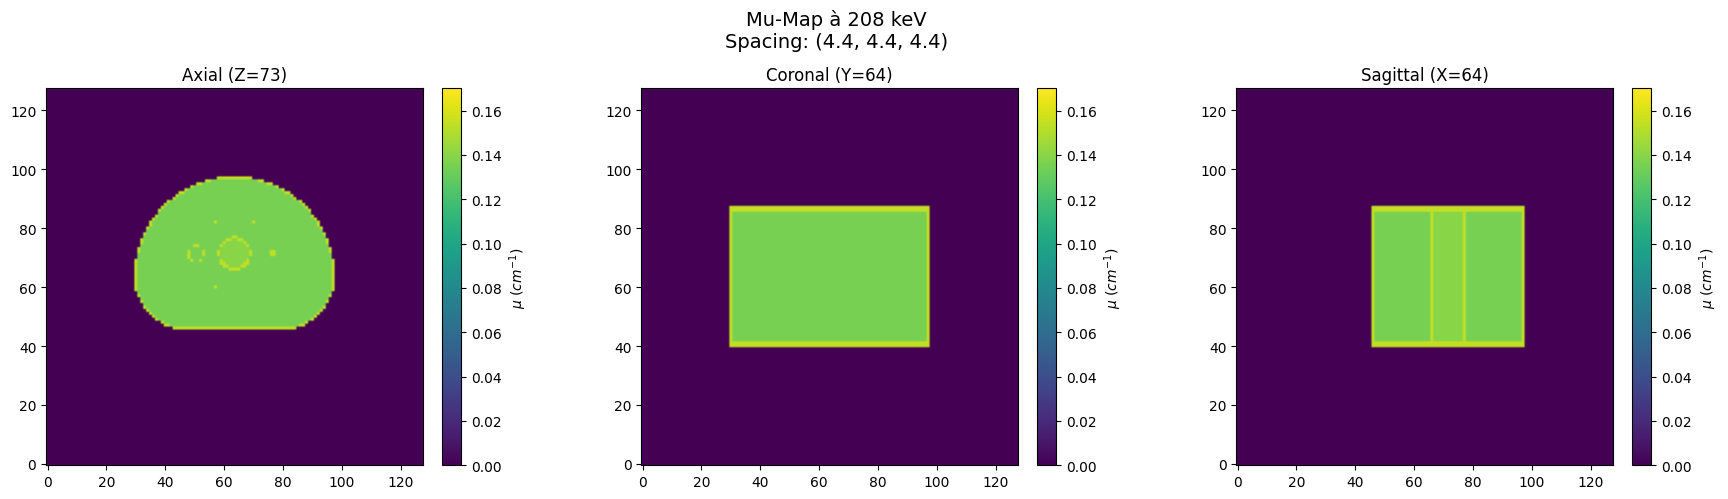

In [665]:
path_mu = "../../../../simulations-kernel-esse/validation_tests/nema_maps/nema_mu_map_208keV.mhd"
plot_mhd(path_mu, title="Mu-Map à 208 keV",pos=[73, None, None])

In [666]:
def plot_mhd(mhd_path, title="Mu-Map à 208 keV", pos=[None, None, None]):
    img = sitk.ReadImage(mhd_path)
    data = sitk.GetArrayFromImage(img)
    cz, cy, cx = [s // 2 for s in data.shape]
    if pos[0] is not None:
        cz = min(pos[0], data.shape[0] - 1)
    if pos[1] is not None:
        cy = min(pos[1], data.shape[1] - 1)
    if pos[2] is not None:
        cx = min(pos[2], data.shape[2] - 1)

    # --- Définition du référentiel commun ---
    v_min, v_max = 0.0, data.max() * 1.1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title}\nSpacing: {img.GetSpacing()}", fontsize=14)

    views = [
        (data[cz, :, :], f"Axial (Z={cz})"),
        (data[:, cy, :], f"Coronal (Y={cy})"),
        (data[:, :, cx], f"Sagittal (X={cx})")
    ]

    for i, (slice_data, label) in enumerate(views):
        im = axes[i].imshow(slice_data, cmap='viridis', origin='lower', 
                            vmin=v_min, vmax=v_max) # <--- Échelle fixe
        axes[i].set_title(label)
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04, label="")

    print(f"Valeur min : {data.min():.4f} cm^-1, Valeur max : {data.max():.4f} cm^-1")
    print(f"Slice où on trouve la valeur max : {np.unravel_index(np.argmax(data), data.shape)}")
    print(f"Slice où on trouve la valeur min : {np.unravel_index(np.argmin(data), data.shape)}")

    plt.tight_layout()
    plt.show()

Valeur min : 1.0000 cm^-1, Valeur max : 25.0000 cm^-1
Slice où on trouve la valeur max : (np.int64(75), np.int64(71), np.int64(50))
Slice où on trouve la valeur min : (np.int64(0), np.int64(0), np.int64(0))


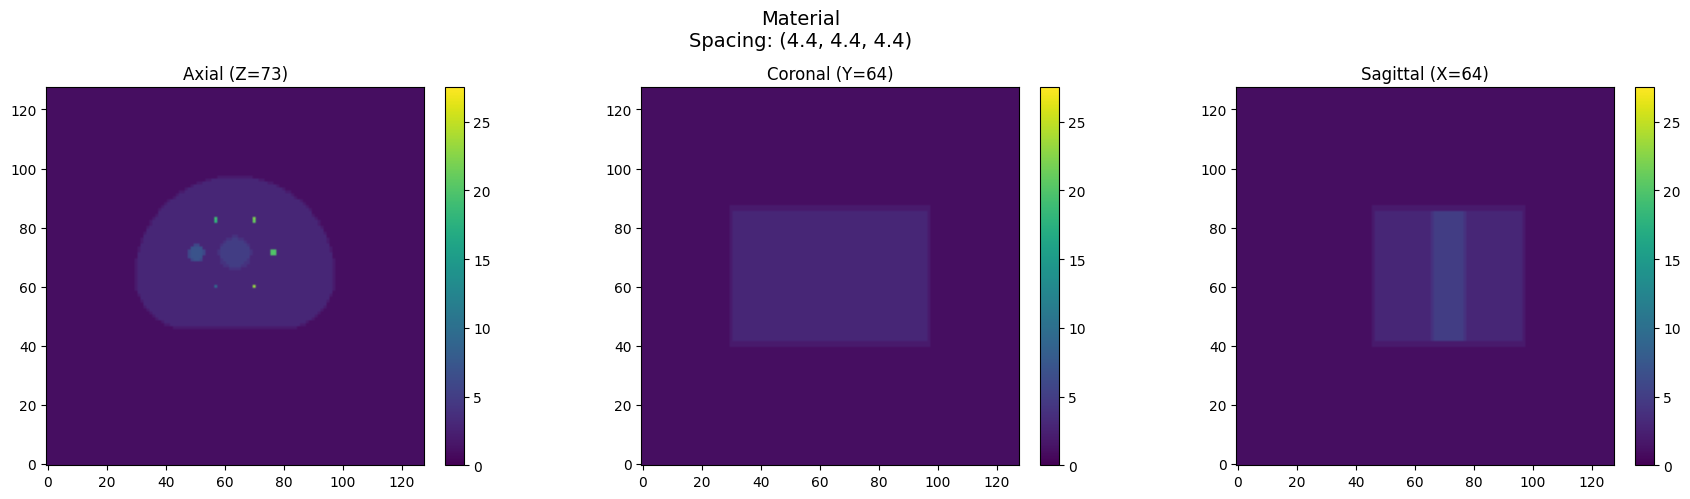

In [667]:
path_test = "../../../../simulations-kernel-esse/validation_tests/nema_maps/nema.mhd"
plot_mhd(path_test, title="Material",pos=[73, None, None])

In [668]:
config = {
    "num_projections": 32,
    "pixel_size_cm": 0.44,
    "matrix_size": 128,
    "filenames": {
        "primary": "projections_primary.mhd",
        "scatter": "projections_scatter.mhd",
        "total": "projections_total.mhd"
    },
    "raws": {
        "primary": "projections_primary.raw",
        "scatter": "projections_scatter.raw",
        "total": "projections_total.raw"
    }
}

path = '../../../../simulations-kernel-esse/validation_tests/output_spect/'

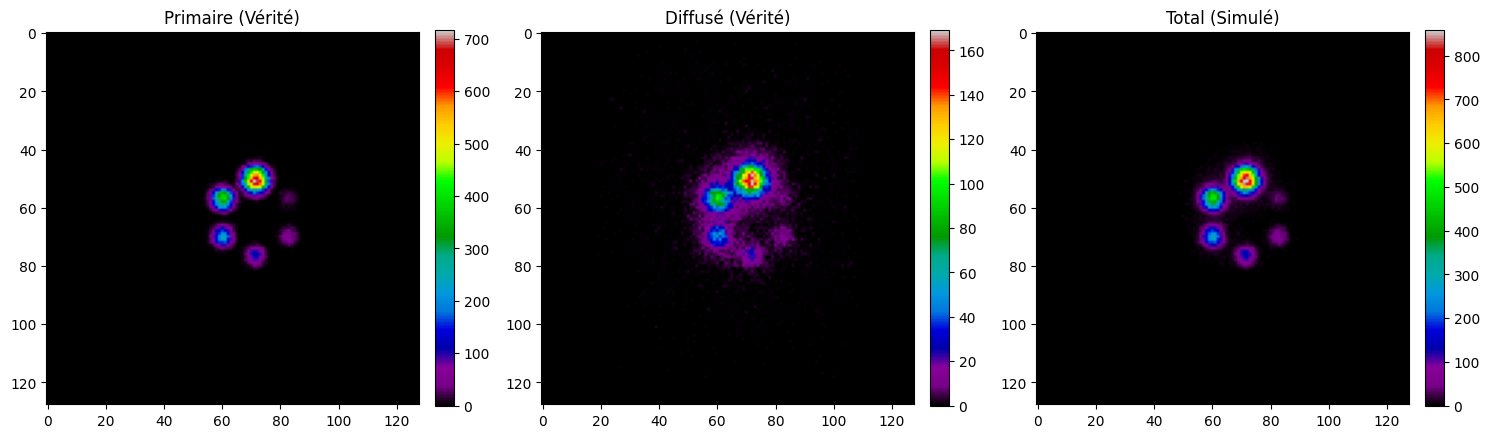

In [669]:
def load_gate_projection(filename):
    img = sitk.ReadImage(filename)
    data = sitk.GetArrayFromImage(img)
    return torch.tensor(data.astype(np.float32))

# Chargement des données
proj_primary = load_gate_projection(path + config["filenames"]["primary"])
proj_scatter = load_gate_projection(path + config["filenames"]["scatter"])
proj_total = load_gate_projection(path + config["filenames"]["total"])
# proj_primary = np.transpose(load_gate_projection(path + config["filenames"]["primary"]), (0, 2, 1))
# proj_scatter = np.transpose(load_gate_projection(path + config["filenames"]["scatter"]), (0, 2, 1))
# proj_total = np.transpose(load_gate_projection(path + config["filenames"]["total"]), (0, 2, 1))    
# proj_primary = np.transpose(load_gate_projection(path + config["filenames"]["primary"]), (2, 1, 0))
# proj_scatter = np.transpose(load_gate_projection(path + config["filenames"]["scatter"]), (2, 1, 0))
# proj_total = np.transpose(load_gate_projection(path + config["filenames"]["total"]), (2, 1, 0)) 

proj_primary = torch.flip(proj_primary, dims=[2])
proj_scatter = torch.flip(proj_scatter, dims=[2])
proj_total = torch.flip(proj_total, dims=[2])

proj_primary = proj_primary.permute(0, 2, 1)
proj_scatter = proj_scatter.permute(0, 2, 1)
proj_total = proj_total.permute(0, 2, 1)


# Affichage d'une projection (ex: angle 0)
angle_idx = 0
plt.figure(figsize=(15, 5))
titles = ['Primaire (Vérité)', 'Diffusé (Vérité)', 'Total (Simulé)']
projs = [proj_primary[angle_idx], proj_scatter[angle_idx], proj_total[angle_idx]]

for i, (p, t) in enumerate(zip(projs, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(t)
    plt.imshow(p.cpu(), cmap='nipy_spectral')
    plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [670]:
def check_raw_integrity(filepath, shape=(20, 128, 128)):
    if not os.path.exists(filepath):
        print(f"Fichier introuvable : {filepath}")
        return

    # Lecture du binaire brut (float32 car MET_FLOAT dans votre mhd)
    data = np.fromfile(filepath, dtype=np.float32)
    
    print(f"--- Analyse de {os.path.basename(filepath)} ---")
    print(f"Nombre total d'éléments : {data.size}")
    print(f"Somme totale des comptes : {data.sum()}")
    print(f"Valeur Max : {data.max()}")
    print(f"Valeur Min : {data.min()}")
    print(f"Nombre de pixels non nuls : {np.count_nonzero(data)}")
    

check_raw_integrity(os.path.join(path, config["raws"]["primary"]))
check_raw_integrity(os.path.join(path, config["raws"]["scatter"]))
check_raw_integrity(os.path.join(path, config["raws"]["total"]))

--- Analyse de projections_primary.raw ---
Nombre total d'éléments : 524288
Somme totale des comptes : 1039609.0
Valeur Max : 738.0
Valeur Min : 0.0
Nombre de pixels non nuls : 20686
--- Analyse de projections_scatter.raw ---
Nombre total d'éléments : 524288
Somme totale des comptes : 580415.0
Valeur Max : 205.0
Valeur Min : 0.0
Nombre de pixels non nuls : 69943
--- Analyse de projections_total.raw ---
Nombre total d'éléments : 524288
Somme totale des comptes : 1620024.0
Valeur Max : 943.0
Valeur Min : 0.0
Nombre de pixels non nuls : 70101


In [671]:
path_data = '/home/chloe/SPECT'  # Personal computer

# pathCT = os.path.join(path_data, 'Lu177-NEMA-SymT2', 'CT')
# files_CT = [os.path.join(pathCT, file) for file in os.listdir(pathCT)]

attenuation_map_path = "../../../../simulations-kernel-esse/validation_tests/nema_maps/nema_mu_map_208keV.mhd"

img = sitk.ReadImage(attenuation_map_path)
attenuation_map_np = sitk.GetArrayFromImage(img)
attenuation_map = torch.from_numpy(attenuation_map_np.astype(np.float32))
attenuation_map = torch.flip(attenuation_map, dims=[2])
attenuation_map = attenuation_map.permute(0, 2, 1)



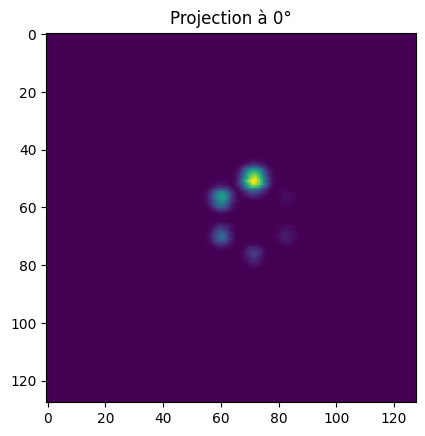

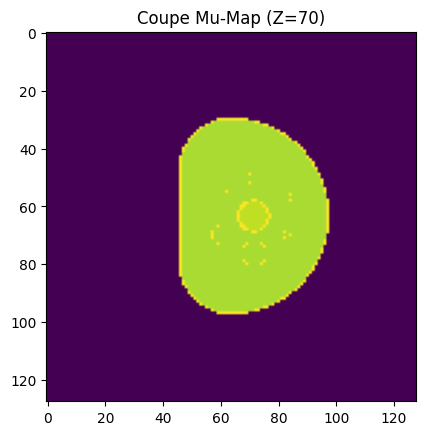

In [672]:
# Affichez la première projection (Angle 0)
plt.imshow(proj_primary[0].cpu().numpy())
plt.title("Projection à 0°")
plt.show()

# Affichez la coupe centrale de la Mu-Map correspondante
plt.imshow(attenuation_map[70].cpu().numpy())
plt.title("Coupe Mu-Map (Z=70)")
plt.show()

In [673]:
pytomography.device = 'cpu'
pytomography.dtype = torch.float32

energy = 208.0
nb_iter= 10
nb_subset= 8
index_peak = 0
photopeak_total = proj_total.to(pytomography.device)
photopeak_primary = proj_primary.to(pytomography.device)

In [674]:
# object_meta, proj_meta = dicom.get_metadata(file_NM)
projections = photopeak_total
projections_primary = photopeak_primary
# attenuation_map_total = dicom.get_attenuation_map_from_CT_slices(files_CT, photopeak_total)
# attenuation_map_primary = dicom.get_attenuation_map_from_CT_slices(files_CT, photopeak_primary)

# attenuation_map_total = attenuation_map
# attenuation_map_primary = attenuation_map
mu_water = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, energy)

In [675]:

collimator_name = 'SY-ME'               #todo: automatiser la récupération du collimateur à partir des métadonnées 
energy_kev = energy
intrinsic_resolution=0.35 # todo : à vérifier ??
psf_meta = dicom.get_psfmeta_from_scanner_params(
        collimator_name,
        energy_kev,
        intrinsic_resolution=intrinsic_resolution
)
psf_transform = SPECTPSFTransform(psf_meta)

with open(path + "/metadata_pytomography.json", "r") as f:
    meta_json = json.load(f)

# Instanciation automatique
proj_meta = SPECTProjMeta(
    projection_shape=(meta_json['simulation_params']['matrix_size'], 
                      meta_json['simulation_params']['matrix_size']),
    angles=np.array(meta_json['geometry']['angles']),
    radii=np.array(meta_json['geometry']['radii_cm']),
    dr=(meta_json['simulation_params']['pixel_size_cm'], 
        meta_json['simulation_params']['pixel_size_cm'])
)
# print(proj_meta.radii)

object_meta = SPECTObjectMeta(
    dr = (meta_json['simulation_params']['pixel_size_cm'], 
          meta_json['simulation_params']['pixel_size_cm'],
          meta_json['simulation_params']['pixel_size_cm']   
    ),
    shape= (meta_json['simulation_params']['matrix_size'], 
            meta_json['simulation_params']['matrix_size'],
            meta_json['simulation_params']['matrix_size']
    )
)

In [676]:
import torch.nn.functional as F

def resample_mu_map(mu_map, object_meta):
    """
    Redimensionne la Mu-Map 3D pour correspondre à la grille de reconstruction.
    """
    # mu_map est un tenseur (Z, Y, X)
    # F.interpolate attend (Batch, Channel, Z, Y, X)
    mu_tensor = mu_map.unsqueeze(0).unsqueeze(0)
    
    # On récupère la shape cible depuis object_meta
    target_shape = object_meta.shape # ex: (128, 128, 128)
    
    # Interpolation trilinéaire
    resampled = F.interpolate(
        mu_tensor, 
        size=target_shape, 
        mode='trilinear', 
        align_corners=False
    ).squeeze()
    
    return resampled

# --- Application ---

mu_aligned = resample_mu_map(attenuation_map, object_meta)
attenuation_map_total = mu_aligned
attenuation_map_primary = mu_aligned
attenuation_map_total = attenuation_map_total
attenuation_map_primary = attenuation_map_primary
att_transform_total = SPECTAttenuationTransform(attenuation_map=attenuation_map_total)
att_transform_primary = SPECTAttenuationTransform(attenuation_map=attenuation_map_primary)

In [677]:
# mu_aligned = torch.roll(mu_aligned, shifts=64, dims=0)  # Décale d'une demi-grille

In [678]:
system_matrix_no_correction = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_correction = PoissonLogLikelihood(system_matrix_no_correction, photopeak_total)
algorithm_no_correction = OSEM(likelihood_no_correction)

In [679]:
recon_no_correction = algorithm_no_correction(n_iters=nb_iter, n_subsets=nb_subset)

In [680]:
system_matrix_no_scatter = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_primary, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_scatter = PoissonLogLikelihood(system_matrix_no_scatter, photopeak_primary)
algorithm_no_scatter = OSEM(likelihood_no_scatter)

In [681]:
recon_no_scatter = algorithm_no_scatter(n_iters=nb_iter, n_subsets=nb_subset)

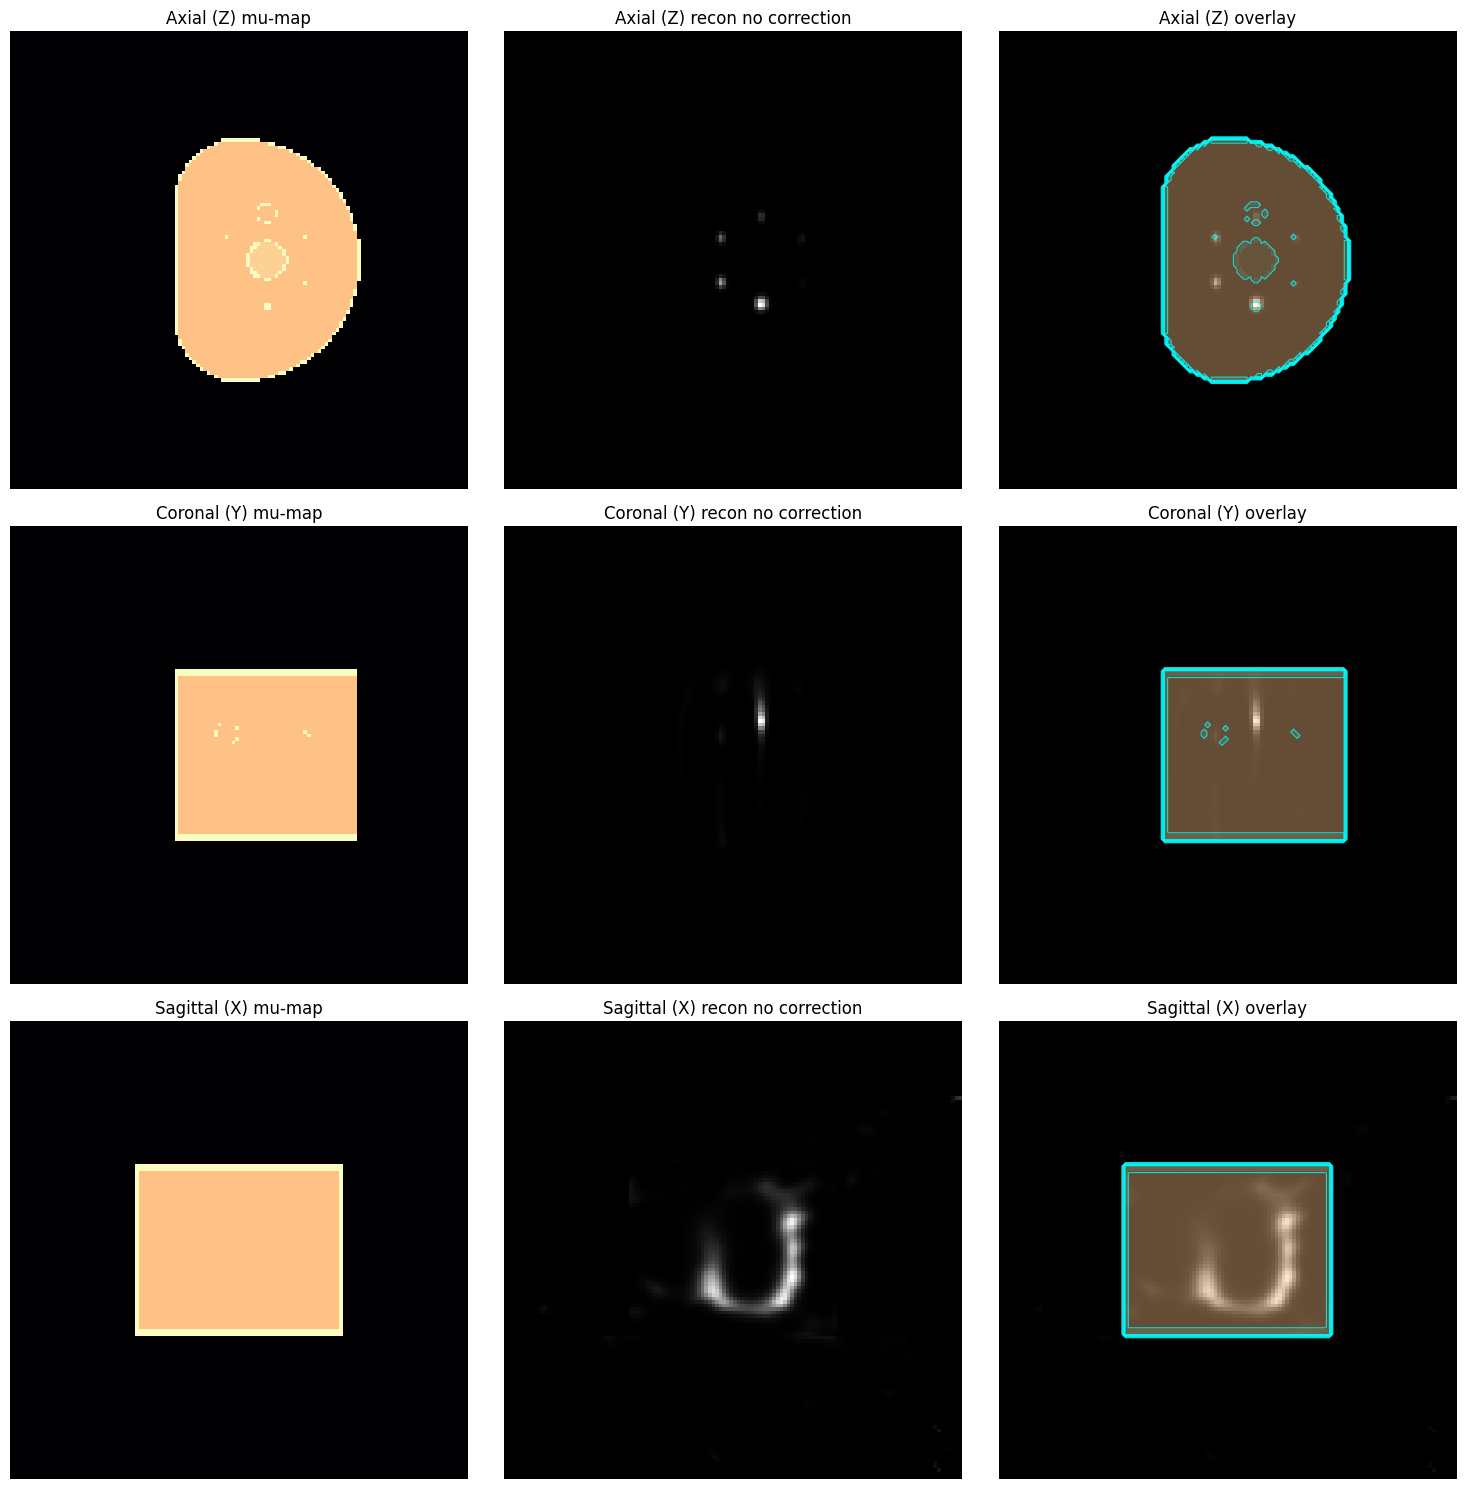

In [682]:
def _to_np(x):
    return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

def _norm01(img):
    img = img.astype(np.float32)
    vmin, vmax = np.percentile(img, [1, 99])
    if vmax <= vmin:
        vmin, vmax = img.min(), img.max()
    return np.clip((img - vmin) / (vmax - vmin + 1e-8), 0.0, 1.0)

mu_vol = _to_np(attenuation_map_total)
recon_vol = _to_np(recon_no_correction)

assert mu_vol.shape == recon_vol.shape, f"Shapes différentes: mu {mu_vol.shape}, recon {recon_vol.shape}"

cz, cy, cx = [s // 2 for s in mu_vol.shape]
cz = 73
cy = 71
cx = 51

# views = [
#     ("Axial (Z)", mu_vol[cz, :, :], recon_vol[cz, :, :]),
#     ("Coronal (Y)", mu_vol[:, cy, :], recon_vol[:, cy, :]),
#     ("Sagittal (X)", mu_vol[:, :, cx], recon_vol[:, :, cx]),
# ]

views = [
    ("Axial (Z)", mu_vol[cz, :, :], recon_vol[:, cy, :]),
    ("Coronal (Y)", mu_vol[:, cy, :], recon_vol[cz, :, :]),
    ("Sagittal (X)", mu_vol[:, :, cx], recon_vol[:, :, cx]),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row, (title, mu_slice, recon_slice) in enumerate(views):
    mu_n = _norm01(mu_slice)
    recon_n = recon_slice

    axes[row, 0].imshow(mu_n, cmap="magma", origin="lower")
    axes[row, 0].set_title(f"{title} mu-map")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(recon_n, cmap="gray", origin="lower")
    axes[row, 1].set_title(f"{title} recon no correction")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(recon_n, cmap="gray", origin="lower")
    axes[row, 2].imshow(mu_n, cmap="magma", alpha=0.40, origin="lower")
    axes[row, 2].contour(mu_n, levels=6, colors="cyan", linewidths=0.8, alpha=0.8)
    axes[row, 2].set_title(f"{title} overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [683]:
#todo suppr
z,y,x = np.unravel_index(
    np.argmax(recon_vol),
    recon_vol.shape
)

print(z,y,x)

51 69 71


Text(0.5, 1.0, 'mu[:,:,x]')

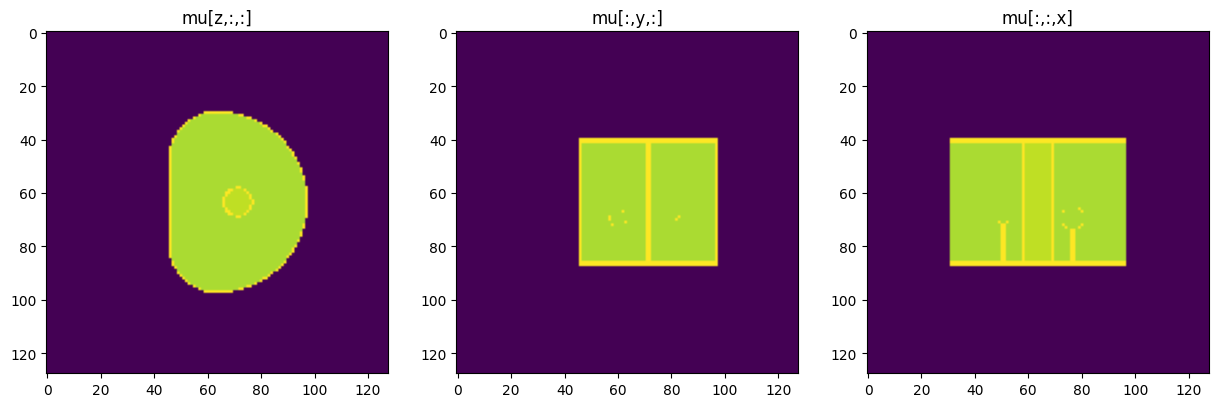

In [684]:
fig,ax = plt.subplots(1,3,figsize=(15,5))

ax[0].imshow(mu_vol[z,:,:])
ax[0].set_title("mu[z,:,:]")

ax[1].imshow(mu_vol[:,y,:])
ax[1].set_title("mu[:,y,:]")

ax[2].imshow(mu_vol[:,:,x])
ax[2].set_title("mu[:,:,x]")

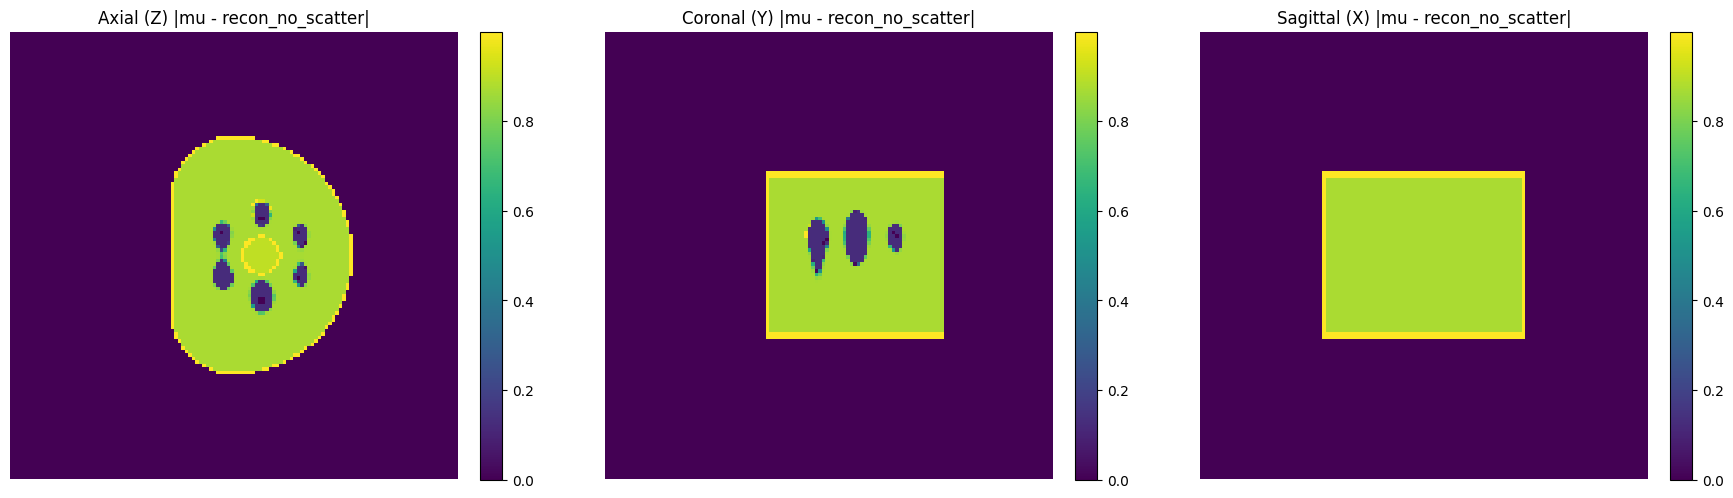

In [685]:
# Plot |mu - recon_no_scatter| for axial/coronal/sagittal
recon_ns = _to_np(recon_no_scatter)
cz, cy, cx = [s // 2 for s in mu_vol.shape]
cz = 73
cy = 71
cx = 51

views_ns = [
    ("Axial (Z)", mu_vol[cz, :, :], recon_ns[:, cy, :]),
    ("Coronal (Y)", mu_vol[:, cy, :], recon_ns[cz, :, :]),
    ("Sagittal (X)", mu_vol[:, :, cx], recon_ns[:, :, cx]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (title, mu_slice, recon_slice) in enumerate(views_ns):
    diff = abs(_norm01(mu_slice) - _norm01(recon_slice))
    axes[i].imshow(diff, cmap="viridis", origin="lower")
    axes[i].set_title(f"{title} |mu - recon_no_scatter|")
    axes[i].axis("off")
    plt.colorbar(axes[i].imshow(diff, cmap="viridis", origin="lower"), ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

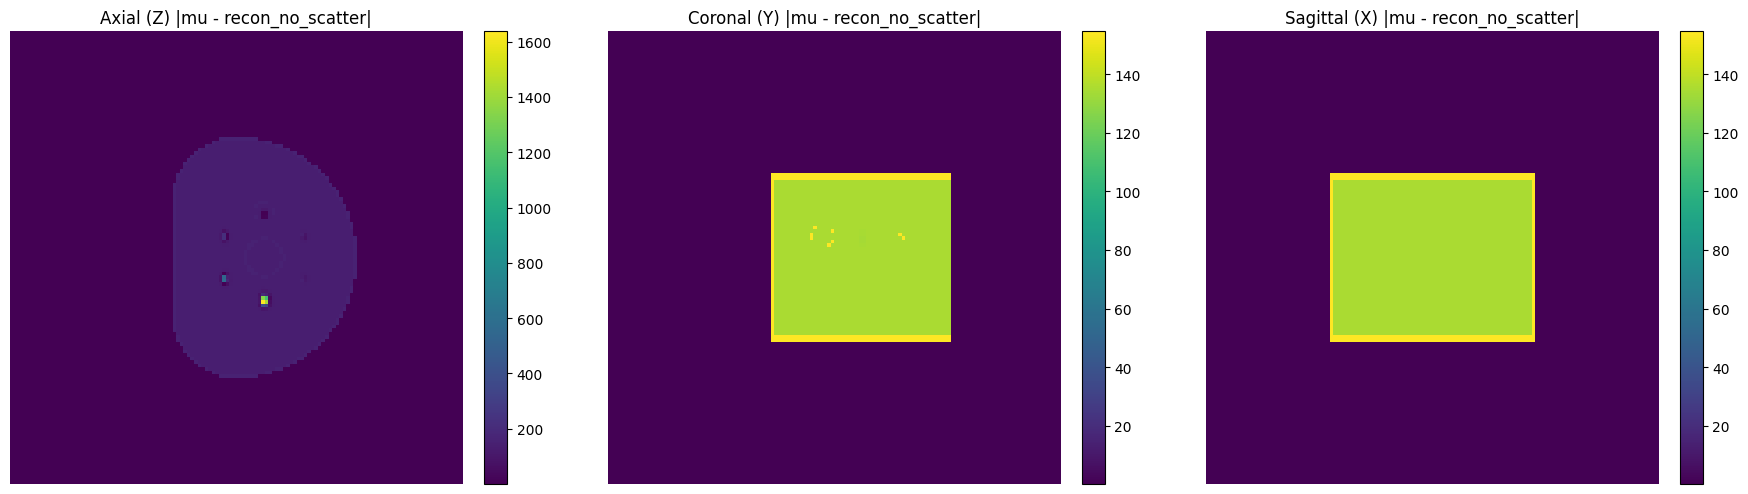

In [686]:
# Plot |mu - recon_no_scatter| for axial/coronal/sagittal
recon_ns = _to_np(recon_no_scatter)
cz, cy, cx = [s // 2 for s in mu_vol.shape]
cz = 73
cy = 71
cx = 51

views_ns = [
    ("Axial (Z)", mu_vol[cz, :, :], recon_ns[:, cy, :]),
    ("Coronal (Y)", mu_vol[:, cy, :], recon_ns[cz, :, :]),
    ("Sagittal (X)", mu_vol[:, :, cx], recon_ns[:, :, cx]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (title, mu_slice, recon_slice) in enumerate(views_ns):
    diff = abs(1000*mu_slice - recon_slice)
    axes[i].imshow(diff, cmap="viridis", origin="lower")
    axes[i].set_title(f"{title} |mu - recon_no_scatter|")
    axes[i].axis("off")
    plt.colorbar(axes[i].imshow(diff, cmap="viridis", origin="lower"), ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [687]:
import numpy as np
from scipy.stats import pearsonr

def corrcoef3d(a, b):
    return pearsonr(
        a.ravel(),
        b.ravel()
    )[0]

def test_all_axis_permutations(ref, img):

    perms = {
        "(Z,Y,X)": (0,1,2),
        "(Z,X,Y)": (0,2,1),
        "(Y,Z,X)": (1,0,2),
        "(Y,X,Z)": (1,2,0),
        "(X,Z,Y)": (2,0,1),
        "(X,Y,Z)": (2,1,0),
    }

    results = []

    for name, perm in perms.items():

        moved = np.transpose(img, perm)

        c = corrcoef3d(ref, moved)

        results.append((name, c))

    results.sort(key=lambda x: abs(x[1]), reverse=True)

    print("\n=== AXIS PERMUTATION TEST ===\n")

    for name, c in results:
        print(f"{name:10s}  corr={c:.6f}")

    return results

test_all_axis_permutations(
    mu_vol,
    recon_vol
)


=== AXIS PERMUTATION TEST ===

(Z,Y,X)     corr=0.034581
(Z,X,Y)     corr=0.034286
(X,Z,Y)     corr=0.034130
(Y,Z,X)     corr=0.034022
(Y,X,Z)     corr=0.033802
(X,Y,Z)     corr=0.033753


[('(Z,Y,X)', np.float32(0.03458119)),
 ('(Z,X,Y)', np.float32(0.034286156)),
 ('(X,Z,Y)', np.float32(0.03413023)),
 ('(Y,Z,X)', np.float32(0.034021538)),
 ('(Y,X,Z)', np.float32(0.033801574)),
 ('(X,Y,Z)', np.float32(0.03375331))]

In [688]:
proj_lower = load_gate_projection(path + "projections_scatter3.mhd").to(pytomography.device)
proj_upper = load_gate_projection(path + "projections_scatter4.mhd").to(pytomography.device)

scatter_TEW = compute_EW_scatter(
    projection_lower=proj_lower,
    projection_upper=proj_upper,
    width_lower=14.9,
    width_upper=18.66,
    width_peak=31.2,
    weighting_lower=0.5,
    weighting_upper=0.5,
    proj_meta=proj_meta,
    # sigma_r=0.48,
    # sigma_z=0.48,
    # sigma_theta=2.0
)

system_matrix_TEW = SPECTSystemMatrix(
    obj2obj_transforms=[att_transform_total, psf_transform],
    proj2proj_transforms = [],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_TEW = PoissonLogLikelihood(
    system_matrix_TEW, 
    photopeak_total,
    scatter_TEW
)

algorithm_TEW = OSEM(likelihood_TEW)
recon_TEW = algorithm_TEW(n_iters=nb_iter, n_subsets=nb_subset)

In [ ]:
from scipy.ndimage import gaussian_filter, uniform_filter 

npy_file = '../../../../simulations-kernel-esse/esse_kernels/output/esse_kernels_3d.npy'
npy_file_amu = '../../../../simulations-kernel-esse/esse_kernels/output/esse_amu_kernels_3d.npy'

FILE_WATER = os.path.join(DATADIR, 'water.csv')
mu_water = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, energy)

# from scipy.ndimage import gaussian_filter
def get_real_esse_kernels(npy_path, npy_path_amu, grid_size):

    Z_t, Y_t, X_t = grid_size

    # --- LOAD ---
    raw_k0 = np.load(npy_path)
    raw_amu = np.load(npy_path_amu)
    print(f"Raw K0 shape: {raw_k0.shape}, Raw AMU shape: {raw_amu.shape}")

    #plot la première coupe du noyau
    plt.imshow(raw_k0[:,5,:], cmap='viridis')
    plt.title("Coupe centrale du noyau ESSE brut")
    plt.colorbar(label="Valeurs du noyau")
    plt.show()

    print("avant lissage :", raw_k0.sum())
    # raw_k0 = gaussian_filter(raw_k0, sigma=(0.2, 0, 0.2))
    # raw_amu = gaussian_filter(raw_amu, sigma=(0.2, 0, 0.2))

    # raw_k0 = gaussian_filter(raw_k0, sigma=(2, 0, 2))
    # raw_amu = gaussian_filter(raw_amu, sigma=(2, 0, 2))

    #changer de filtre de lissage, autre chose que le gaussien
    # raw_k0 = uniform_filter(raw_k0, size=(3, 3, 1))
    # raw_amu = uniform_filter(raw_amu, size=(3, 3, 1))
    print("après lissage :", raw_k0.sum())
    # --- FORMAT ---
    if raw_k0.ndim == 3:
        # k0 = np.transpose(raw_k0, (1, 2, 0))
        # amu = np.transpose(raw_amu, (1, 2, 0))
        k0 = np.transpose(raw_k0, (1, 0, 2))
        amu = np.transpose(raw_amu, (1, 0, 2))
    else:
        k0 = raw_k0
        amu = raw_amu

    print(amu.min(), amu.max(), amu.mean())

    # delta_mu = amu - mu_water
    # print(f"Delta mu (AMU - mu_water): min={delta_mu.min():.4f}, max={delta_mu.max():.4f}, mean={delta_mu.mean():.4f}")
    # print(f"mu_water: {mu_water:.4f}")
    # --- TAYLOR TERMS ---
    # K0 = k0
    # K1 = k0 * amu
    # K2 = 0.5 * k0 * (amu ** 2)

    K0 = k0
    K1 = k0 * amu
    K2 = 0.5 * k0 * (amu ** 2)
    # K2 = k0 * (amu ** 2)

    def pad_kernel(data):
        Z_s, Y_s, X_s = data.shape 

        pad_z = Z_t - Z_s
        pad_y = Y_t - Y_s
        pad_x = X_t - X_s

        paddings = (
            pad_x // 2, pad_x - (pad_x // 2), # Dim X
            pad_y // 2, pad_y - (pad_y // 2), # Dim Y
            pad_z // 2, pad_z - (pad_z // 2)  # Dim Z
        )

        tensor = torch.from_numpy(data).float()
        return torch.nn.functional.pad(tensor, paddings)

    # --- APPLY PADDING ---
    k0_t = pad_kernel(K0)
    k1_t = pad_kernel(K1)
    k2_t = pad_kernel(K2)

    # --- STACK FINAL ---
    final_kernels = torch.stack([
        k0_t,
        k1_t,
        k2_t
    ])

    print(f"Kernel shape after padding: {final_kernels.shape} (should be [3, Z_t, Y_t, X_t])")

    return final_kernels


Raw K0 shape: (64, 10, 64), Raw AMU shape: (64, 10, 64)


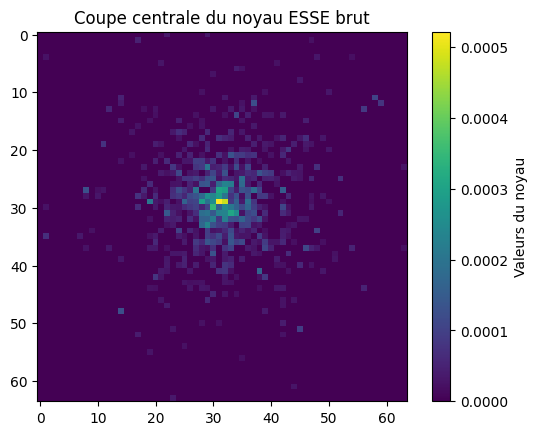

avant lissage : 0.3228915300882211
après lissage : 0.3228915300882211
0.0 0.13889929690063932 0.01162829190992958
Kernel shape after padding: torch.Size([3, 182, 182, 128]) (should be [3, Z_t, Y_t, X_t])
torch.Size([3, 182, 182, 128])


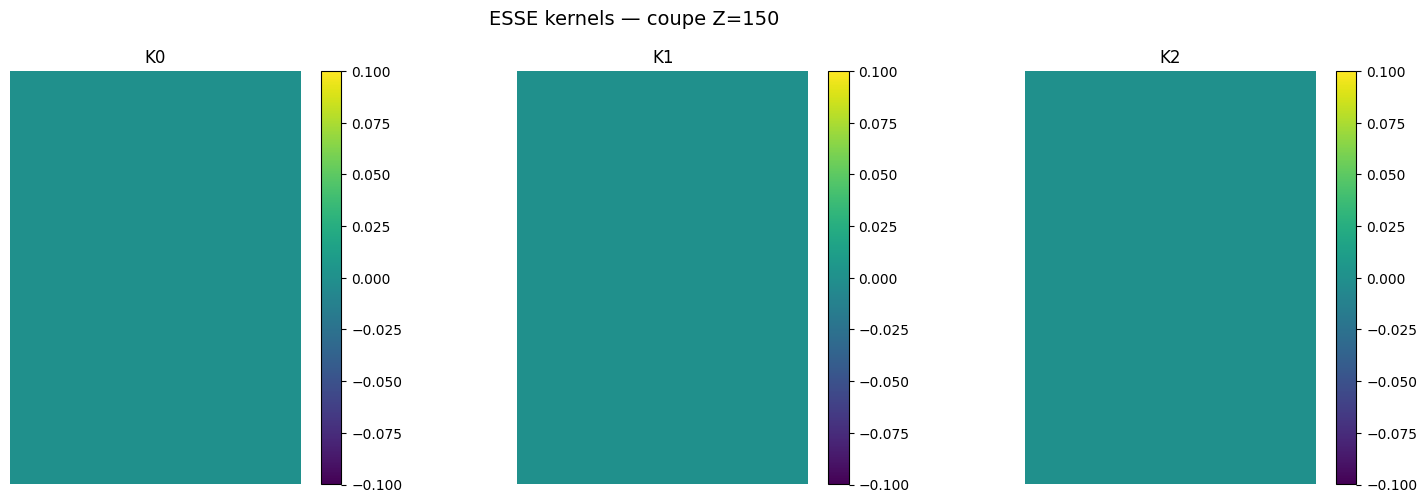

Max value in K0: 0.0015, Max value in K1: 0.0002, Max value in K2: 0.0000


In [690]:
def plot_esse_kernels(kernels, layer_idx=None, axis=0, cmap="viridis"):
    """
    Affiche les 3 kernels ESSE pour une couche donnée.
    axis = 0 (Z), 1 (Y), 2 (X)
    """
    k = kernels.detach().cpu().numpy() if isinstance(kernels, torch.Tensor) else np.asarray(kernels)
    assert k.ndim == 4 and k.shape[0] == 3, f"Shape attendue: [3, Z, Y, X], reçu {k.shape}"

    if layer_idx is None:
        layer_idx = k.shape[axis + 1] // 2

    if axis == 0:
        slices = [k[i, layer_idx, :, :] for i in range(3)]
        axis_name = f"Z={layer_idx}"
    elif axis == 1:
        slices = [k[i, :, layer_idx, :] for i in range(3)]
        axis_name = f"Y={layer_idx}"
    else:
        slices = [k[i, :, :, layer_idx] for i in range(3)]
        axis_name = f"X={layer_idx}"

    vmax = np.percentile(np.concatenate([s.ravel() for s in slices]), 99)
    vmin = np.percentile(np.concatenate([s.ravel() for s in slices]), 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"ESSE kernels — coupe {axis_name}", fontsize=14)

    for i, (ax, sl) in enumerate(zip(axes, slices)):
        im = ax.imshow(sl, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(f"K{i}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


kernels = get_real_esse_kernels(
    npy_path=npy_file,
    npy_path_amu=npy_file_amu,
    grid_size=object_meta.padded_shape
)

print(kernels.shape)

plot_esse_kernels(kernels, layer_idx=150, axis=0)
print(f"Max value in K0: {kernels[0].max():.4f}, Max value in K1: {kernels[1].max():.4f}, Max value in K2: {kernels[2].max():.4f}")

In [691]:
from scipy.ndimage import center_of_mass
import numpy as np
import torch

def diag_kernel(name, k):
    if isinstance(k, torch.Tensor):
        k = k.detach().cpu().numpy()

    print(f"\n===== {name} =====")

    print("shape :", k.shape)
    print("sum   :", k.sum())
    print("min   :", k.min())
    print("max   :", k.max())
    print("mean  :", k.mean())

    com = center_of_mass(np.abs(k))
    print("COM   :", com)

    argmax = np.unravel_index(np.argmax(np.abs(k)), k.shape)
    print("argmax:", argmax)

    center = tuple(s//2 for s in k.shape)
    print("center:", center)

    print("offset from center:",
          tuple(np.round(argmax[i]-center[i],2)
                for i in range(len(center))))

print("\n========================")
print("MU CONSISTENCY")
print("========================")

print("mu_water =", mu_water)

raw_amu = np.load(npy_file_amu)

print("amu min  =", raw_amu.min())
print("amu max  =", raw_amu.max())
print("amu mean =", raw_amu.mean())

delta_mu = raw_amu - mu_water

print("\ndelta_mu stats")
print("min  =", delta_mu.min())
print("max  =", delta_mu.max())
print("mean =", delta_mu.mean())

print("\n========================")
print("KERNEL ANALYSIS")
print("========================")

diag_kernel("K0", kernels[0])
diag_kernel("K1", kernels[1])
diag_kernel("K2", kernels[2])

print("\n========================")
print("ENERGY CHECK")
print("========================")

print("ESSE energy =", 208.4)
print("mu energy   =", energy)

print("\n========================")
print("NORMALIZATION")
print("========================")

for i in range(3):
    k = kernels[i].cpu().numpy()
    print(f"K{i} sum abs =", np.abs(k).sum())
    print(f"K{i} sum     =", k.sum())


MU CONSISTENCY
mu_water = 0.13528774350209752
amu min  = 0.0
amu max  = 0.13889929690063932
amu mean = 0.01162829190992958

delta_mu stats
min  = -0.13528774350209752
max  = 0.0036115533985418002
mean = -0.12365945159216796

KERNEL ANALYSIS

===== K0 =====
shape : (182, 182, 128)
sum   : 0.32289153
min   : 0.0
max   : 0.0015096056
mean  : 7.615596e-08
COM   : (np.float64(89.1271153396079), np.float64(86.99130603524982), np.float64(63.67765116400134))
argmax: (np.int64(88), np.int64(86), np.int64(64))
center: (91, 91, 64)
offset from center: (np.int64(-3), np.int64(-5), np.int64(0))

===== K1 =====
shape : (182, 182, 128)
sum   : 0.043500043
min   : 0.0
max   : 0.0002053384
mean  : 1.0259754e-08
COM   : (np.float64(89.1195600602147), np.float64(86.95744701890409), np.float64(63.67370608170574))
argmax: (np.int64(88), np.int64(86), np.int64(64))
center: (91, 91, 64)
offset from center: (np.int64(-3), np.int64(-5), np.int64(0))

===== K2 =====
shape : (182, 182, 128)
sum   : 0.0029325313


--- proj_meta ---
type=<class 'pytomography.metadata.SPECT.spect_metadata.SPECTProjMeta'>
angles count=32
radii count=32
dr=(0.44000000000000006, 0.44000000000000006)
derived projection_shape=(angles=32, radii=32)

--- system_matrix_no_correction ---
type=<class 'pytomography.projectors.SPECT.dualhead_system_matrix.SPECTSystemMatrix'>
proj_meta: angles=32, radii=32
n_obj2obj_transforms=2
n_proj2proj_transforms=0

--- system_matrix_no_scatter ---
type=<class 'pytomography.projectors.SPECT.dualhead_system_matrix.SPECTSystemMatrix'>
proj_meta: angles=32, radii=32
n_obj2obj_transforms=2
n_proj2proj_transforms=0

--- system_matrix_TEW ---
type=<class 'pytomography.projectors.SPECT.dualhead_system_matrix.SPECTSystemMatrix'>
proj_meta: angles=32, radii=32
n_obj2obj_transforms=2
n_proj2proj_transforms=0

--- system_matrix_ESSE ---
type=<class 'pytomography.projectors.SPECT.dualhead_system_matrix.SPECTSystemMatrix'>
proj_meta: angles=32, radii=32
n_obj2obj_transforms=2
n_proj2proj_transforms=0

argmax(abs)=(np.int64(40), np.int64(30), np.int64(59)), edge_hit=False
center_of_mass(abs)=(np.float64(63.5), np.float64(63.5), np.float64(69.3))

--- raw_k0 (.npy) ---
shape=(64, 10, 64), dtype=float64
min=0, max=0.00150961, sum=0.322892
nonzero(|x|>0)=3541, nonzero(|x|>1e-12)=3541
nan=0, inf=0
argmax(abs)=(np.int64(27), np.int64(2), np.int64(32)), edge_hit=False
center_of_mass(abs)=(np.float64(27.99), np.float64(3.13), np.float64(31.68))

--- raw_amu (.npy) ---
shape=(64, 10, 64), dtype=float64
min=0, max=0.138899, sum=476.295
nonzero(|x|>0)=3541, nonzero(|x|>1e-12)=3541
nan=0, inf=0
argmax(abs)=(np.int64(27), np.int64(6), np.int64(20)), edge_hit=False
center_of_mass(abs)=(np.float64(28.56), np.float64(3.81), np.float64(31.5))
raw_k0.ndim=3, raw_amu.ndim=3
raw_k0 transposed shape -> (10, 64, 64)
raw_amu transposed shape -> (10, 64, 64)

--- ESSE kernels ---
shape=(3, 182, 182, 128), dtype=float32
min=0, max=0.00150961, sum=0.369324
nonzero(|x|>0)=10623, nonzero(|x|>1e-12)=10623
nan=0

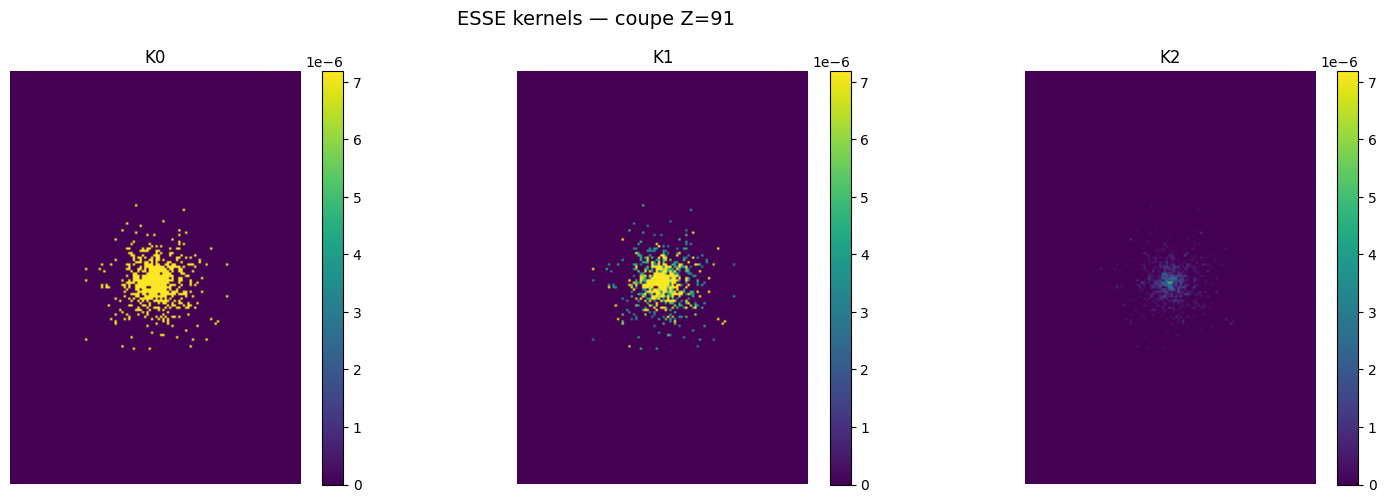


--- proj_primary ---
shape=(32, 128, 128), dtype=float32
min=0, max=738, sum=1.03961e+06
nonzero(|x|>0)=20686, nonzero(|x|>1e-12)=20686
nan=0, inf=0
argmax(abs)=(np.int64(31), np.int64(52), np.int64(72)), edge_hit=True
center_of_mass(abs)=(np.float64(16.21), np.float64(62.8), np.float64(68.15))

--- proj_scatter ---
shape=(32, 128, 128), dtype=float32
min=0, max=205, sum=580415
nonzero(|x|>0)=69943, nonzero(|x|>1e-12)=69943
nan=0, inf=0
argmax(abs)=(np.int64(31), np.int64(52), np.int64(72)), edge_hit=True
center_of_mass(abs)=(np.float64(16.0), np.float64(63.22), np.float64(67.94))

--- proj_total ---
shape=(32, 128, 128), dtype=float32
min=0, max=943, sum=1.62002e+06
nonzero(|x|>0)=70101, nonzero(|x|>1e-12)=70101
nan=0, inf=0
argmax(abs)=(np.int64(31), np.int64(52), np.int64(72)), edge_hit=True
center_of_mass(abs)=(np.float64(16.13), np.float64(62.95), np.float64(68.07))

--- photopeak_primary ---
shape=(32, 128, 128), dtype=float32
min=0, max=738, sum=1.03961e+06
nonzero(|x|>0)=20686

In [692]:
def summarize_array(name, x, nz_eps=1e-12):
    arr = x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)
    print(f"\n--- {name} ---")
    print(f"shape={arr.shape}, dtype={arr.dtype}")
    print(f"min={arr.min():.6g}, max={arr.max():.6g}, sum={arr.sum():.6g}")
    print(f"nonzero(|x|>0)={np.count_nonzero(arr)}, nonzero(|x|>{nz_eps})={np.count_nonzero(np.abs(arr) > nz_eps)}")
    print(f"nan={np.isnan(arr).sum()}, inf={np.isinf(arr).sum()}")
    if arr.size and np.any(np.abs(arr) > 0):
        w = np.abs(arr)
        coords = np.indices(arr.shape, dtype=np.float64)
        com = [(coords[i] * w).sum() / (w.sum() + 1e-30) for i in range(arr.ndim)]
        argmax = np.unravel_index(np.argmax(np.abs(arr)), arr.shape)
        edge_hit = any(argmax[i] in (0, arr.shape[i] - 1) for i in range(arr.ndim))
        print(f"argmax(abs)={argmax}, edge_hit={edge_hit}")
        print(f"center_of_mass(abs)={tuple(round(v, 2) for v in com)}")
    else:
        print("array is all zeros")


def diagnose_kernels_and_matrices():
    # ---- Raw files ----
    if 'npy_file' in globals() and 'npy_file_amu' in globals():
        raw_k0 = np.load(npy_file)
        raw_amu = np.load(npy_file_amu)
        summarize_array("raw_k0 (.npy)", raw_k0)
        summarize_array("raw_amu (.npy)", raw_amu)
        print(f"raw_k0.ndim={raw_k0.ndim}, raw_amu.ndim={raw_amu.ndim}")
        if raw_k0.ndim == 3 and raw_amu.ndim == 3:
            print(f"raw_k0 transposed shape -> {(raw_k0.transpose(1,2,0)).shape}")
            print(f"raw_amu transposed shape -> {(raw_amu.transpose(1,2,0)).shape}")
    else:
        print("npy_file / npy_file_amu not available")

    # ---- Final kernels ----
    k = globals().get("kernels", None)
    if k is None and 'get_real_esse_kernels' in globals() and 'object_meta' in globals():
        k = get_real_esse_kernels(npy_file, npy_file_amu, object_meta.padded_shape)

    if k is not None:
        summarize_array("ESSE kernels", k)
        k_np = k.detach().cpu().numpy() if isinstance(k, torch.Tensor) else np.asarray(k)

        if k_np.ndim == 4 and k_np.shape[0] == 3:
            support = np.abs(k_np) > 1e-12
            for i, ki in enumerate(k_np):
                print(f"\nK{i}: sum={ki.sum():.6g}, max={ki.max():.6g}, min={ki.min():.6g}, support={support[i].sum()}")
                print(f"K{i} argmax(abs)={np.unravel_index(np.argmax(np.abs(ki)), ki.shape)}")
                if i > 0:
                    inter = np.logical_and(support[0], support[i]).sum()
                    union = np.logical_or(support[0], support[i]).sum()
                    print(f"Jaccard(K0,K{i})={inter / (union + 1e-30):.4f}")

            if 'object_meta' in globals():
                expected = getattr(object_meta, "padded_shape", getattr(object_meta, "shape", None))
                print(f"\nobject_meta.shape={getattr(object_meta, 'shape', None)}")
                print(f"object_meta.padded_shape={getattr(object_meta, 'padded_shape', None)}")
                print(f"expected kernel grid={expected}")
                print(f"kernel grid={k_np.shape[1:]}")
                if expected is not None and tuple(expected) != tuple(k_np.shape[1:]):
                    print("WARNING: kernel grid does not match object_meta padded shape")

            # quick visual check
            try:
                plot_esse_kernels(k, layer_idx=k_np.shape[1] // 2, axis=0)
            except Exception as e:
                print(f"plot_esse_kernels failed: {e}")
        else:
            print("WARNING: kernel tensor has unexpected shape")
    else:
        print("kernels not available")

    # ---- Projections / attenuation map ----
    for name in [
        "proj_primary", "proj_scatter", "proj_total",
        "photopeak_primary", "photopeak_total",
        "attenuation_map", "attenuation_map_total", "attenuation_map_primary",
        "scatter_TEW"
    ]:
        if name in globals():
            summarize_array(name, globals()[name])

    # ---- Metadata consistency ----
    if 'proj_meta' in globals():
        print("\n--- proj_meta ---")
        print(f"type={type(proj_meta)}")
        print(f"projection_shape={getattr(proj_meta, 'projection_shape', None)}")
        print(f"angles={len(getattr(proj_meta, 'angles', []))}")
        print(f"radii shape={np.asarray(getattr(proj_meta, 'radii', [])).shape}")
        print(f"dr={getattr(proj_meta, 'dr', None)}")

    if 'object_meta' in globals():
        print("\n--- object_meta ---")
        print(f"type={type(object_meta)}")
        print(f"shape={getattr(object_meta, 'shape', None)}")
        print(f"padded_shape={getattr(object_meta, 'padded_shape', None)}")
        print(f"dr={getattr(object_meta, 'dr', None)}")

    # ---- System matrices ----
    for name in [
        "system_matrix_no_correction",
        "system_matrix_no_scatter",
        "system_matrix_TEW",
        "system_matrix_ESSE",
    ]:
        sm = globals().get(name, None)
        if sm is None:
            continue
        print(f"\n--- {name} ---")
        print(f"type={type(sm)}")
        print(f"object_meta.shape={getattr(sm, 'object_meta', None).shape if getattr(sm, 'object_meta', None) is not None else None}")
        # print(f"proj_meta.projection_shape={getattr(sm, 'proj_meta', None).projection_shape if getattr(sm, 'proj_meta', None) is not None else None}")
        print(f"n_obj2obj_transforms={len(getattr(sm, 'obj2obj_transforms', []))}")
        print(f"n_proj2proj_transforms={len(getattr(sm, 'proj2proj_transforms', []))}")
        if getattr(sm, 'scatter_model', None) is not None:
            sc = sm.scatter_model
            print(f"scatter_model={type(sc)}")
            if hasattr(sc, "kernels"):
                summarize_array(f"{name}.scatter_model.kernels", sc.kernels)
            if hasattr(sc, "attenuation_map"):
                summarize_array(f"{name}.scatter_model.attenuation_map", sc.attenuation_map)

    # ---- Likely issue summary ----
    print("\n=== Likely failure signals ===")
    if 'proj_primary' in globals() and torch.count_nonzero(proj_primary) == 0:
        print("proj_primary is all zeros")
    if 'proj_total' in globals() and torch.count_nonzero(proj_total) == 0:
        print("proj_total is all zeros")
    if 'kernels' in globals():
        kk = kernels.detach().cpu()
        if torch.count_nonzero(kk.abs() > 1e-12) == 0:
            print("kernels are effectively all zeros")
    if 'recon_no_scatter' in globals():
        r = recon_no_scatter.detach().cpu()
        if torch.count_nonzero(r > 1e-12) == 0:
            print("recon_no_scatter is effectively all zeros")


# Fix the metadata access for SPECTProjMeta
if 'proj_meta' in globals() and proj_meta is not None:
    print("\n--- proj_meta ---")
    print(f"type={type(proj_meta)}")
    # SPECTProjMeta doesn't have 'projection_shape', derive it from angles and radii
    n_angles = len(getattr(proj_meta, 'angles', []))
    radii = getattr(proj_meta, 'radii', [])
    n_radii = len(radii) if radii is not None else 0
    print(f"angles count={n_angles}")
    print(f"radii count={n_radii}")
    print(f"dr={getattr(proj_meta, 'dr', None)}")
    if n_angles > 0 and n_radii > 0:
        print(f"derived projection_shape=(angles={n_angles}, radii={n_radii})")

# Also fix system matrix metadata access
for name in [
    "system_matrix_no_correction",
    "system_matrix_no_scatter",
    "system_matrix_TEW",
    "system_matrix_ESSE",
]:
    sm = globals().get(name, None)
    if sm is None:
        continue
    print(f"\n--- {name} ---")
    print(f"type={type(sm)}")
    obj_meta = getattr(sm, 'object_meta', None)
    proj_meta_sm = getattr(sm, 'proj_meta', None)
    if proj_meta_sm is not None:
        n_ang = len(getattr(proj_meta_sm, 'angles', []))
        n_rad = len(getattr(proj_meta_sm, 'radii', []))
        print(f"proj_meta: angles={n_ang}, radii={n_rad}")
    print(f"n_obj2obj_transforms={len(getattr(sm, 'obj2obj_transforms', []))}")
    print(f"n_proj2proj_transforms={len(getattr(sm, 'proj2proj_transforms', []))}")
    if getattr(sm, 'scatter_model', None) is not None:
        sc = sm.scatter_model
        print(f"scatter_model={type(sc)}")
        if hasattr(sc, "kernels"):
            summarize_array(f"{name}.scatter_model.kernels", sc.kernels)
        if hasattr(sc, "attenuation_map"):
            summarize_array(f"{name}.scatter_model.attenuation_map", sc.attenuation_map)

diagnose_kernels_and_matrices()

Raw K0 shape: (64, 10, 64), Raw AMU shape: (64, 10, 64)


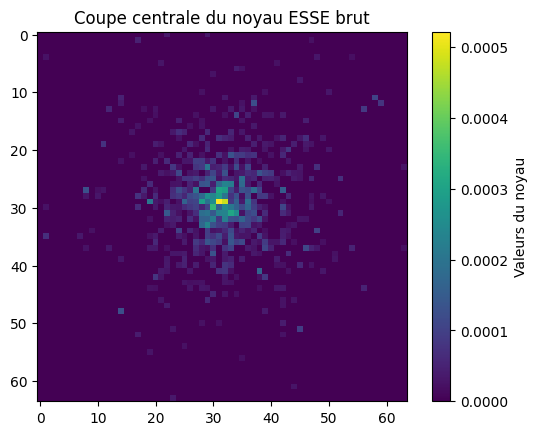

avant lissage : 0.3228915300882211
après lissage : 0.3228915300882211
0.0 0.13889929690063932 0.01162829190992958
Kernel shape after padding: torch.Size([3, 182, 182, 128]) (should be [3, Z_t, Y_t, X_t])


In [693]:
# Initilization

esse = ESSEScatterModel(
    object_meta=object_meta,
    attenuation_map=attenuation_map_total,
    energy=208,
    mu_water=mu_water,
    kernels=get_real_esse_kernels(
        npy_path=npy_file,
        npy_path_amu=npy_file_amu,
        grid_size=object_meta.padded_shape
    )
)

system_matrix_ESSE = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms = [],
    object_meta = object_meta,
    proj_meta = proj_meta,
    scatter_model=esse
)

likelihood_ESSE = PoissonLogLikelihood(system_matrix_ESSE, photopeak_total)
algorithm_ESSE = OSEM(likelihood_ESSE)

In [694]:
print("mu_water =", mu_water)

mu_water = 0.13528774350209752


In [695]:
recon_ESSE = algorithm_ESSE(n_iters=nb_iter, n_subsets=nb_subset)

Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original d

In [696]:
def get_new_esse_kernels(npy_path, grid_size):

    Z_t, Y_t, X_t = grid_size

    # --- LOAD ---
    k = np.load(npy_path)
    print(f"Raw K0 shape: {k.shape}")

    #plot la première coupe du noyau
    plt.imshow(k[1][:,15,:], cmap='viridis')
    plt.title("Coupe centrale du noyau ESSE brut")
    plt.colorbar(label="Valeurs du noyau")
    plt.show()

    # print("avant lissage :", k.sum())
    # raw_k0 = gaussian_filter(raw_k0, sigma=(0.2, 0, 0.2))
    # raw_amu = gaussian_filter(raw_amu, sigma=(0.2, 0, 0.2))

    # k = gaussian_filter(k, sigma=(2, 0, 2))
    # raw_amu = gaussian_filter(raw_amu, sigma=(2, 0, 2))

    #changer de filtre de lissage, autre chose que le gaussien
    # raw_k0 = uniform_filter(raw_k0, size=(3, 3, 1))
    # raw_amu = uniform_filter(raw_amu, size=(3, 3, 1))
    # print("après lissage :", raw_k0.sum())
    # --- FORMAT ---
    # if k.shape[0] == 3:
        # k0 = np.transpose(raw_k0, (1, 2, 0))
        # amu = np.transpose(raw_amu, (1, 2, 0))
        # k = np.transpose(k, (1, 0, 2))
        # amu = np.transpose(raw_amu, (1, 0, 2))

    # delta_mu = amu - mu_water
    # print(f"Delta mu (AMU - mu_water): min={delta_mu.min():.4f}, max={delta_mu.max():.4f}, mean={delta_mu.mean():.4f}")
    # print(f"mu_water: {mu_water:.4f}")
    # --- TAYLOR TERMS ---
    # K0 = k0
    # K1 = k0 * amu
    # K2 = 0.5 * k0 * (amu ** 2)
    
    K0 = k[0]
    K1 = k[1]
    K2 = k[2]

    K0 = (K0 + np.flip(K0, axis=-1) + np.flip(K0, axis=-2) + np.flip(np.flip(K0, axis=-1), axis=-2)) / 4.0
    K1 = (K1 + np.flip(K1, axis=-1) + np.flip(K1, axis=-2) + np.flip(np.flip(K1, axis=-1), axis=-2)) / 4.0
    K2 = (K2 + np.flip(K2, axis=-1) + np.flip(K2, axis=-2) + np.flip(np.flip(K2, axis=-1), axis=-2)) / 4.0

    K0 = gaussian_filter(K0, sigma=2)
    K1 = gaussian_filter(K1, sigma=2)
    K2 = gaussian_filter(K2, sigma=2)
    # K2 = k0 * (amu ** 2)

    def pad_kernel(data, target_shape=(Z_t, Y_t, X_t)):
        Z_s, Y_s, X_s = data.shape 

        pad_z = Z_t - Z_s
        pad_y = Y_t - Y_s
        pad_x = X_t - X_s

        paddings = (
            pad_x // 2, pad_x - (pad_x // 2), # Dim X
            pad_y // 2, pad_y - (pad_y // 2), # Dim Y
            pad_z // 2, pad_z - (pad_z // 2)  # Dim Z
        )

        tensor = torch.from_numpy(data).float()
        return torch.nn.functional.pad(tensor, paddings)

    # --- APPLY PADDING ---
    print(f"K0 shape before padding: {K0.shape}, K1 shape before padding: {K1.shape}, K2 shape before padding: {K2.shape}")
    k0_t = pad_kernel(K0, target_shape=(Z_t, Y_t, X_t))
    k1_t = pad_kernel(K1, target_shape=(Z_t, Y_t, X_t))
    k2_t = pad_kernel(K2, target_shape=(Z_t, Y_t, X_t))

    print("Somme de K0 après padding:", k0_t.sum())
    print("Somme de K1 après padding:", k1_t.sum())
    print("Somme de K2 après padding:", k2_t.sum())

    # --- STACK FINAL ---
    final_kernels = torch.stack([
        k0_t,
        k1_t,
        k2_t
    ])

    return final_kernels



Raw K0 shape: (3, 64, 64, 64)


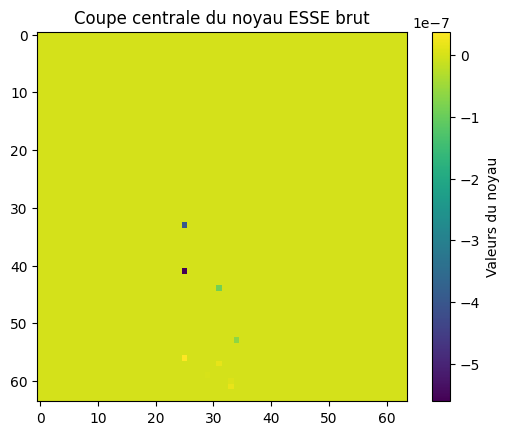

K0 shape before padding: (64, 64, 64), K1 shape before padding: (64, 64, 64), K2 shape before padding: (64, 64, 64)
Somme de K0 après padding: tensor(0.0230)
Somme de K1 après padding: tensor(-1.2605e-05)
Somme de K2 après padding: tensor(4.2212e-07)


In [697]:
npy_file_new_kernels = '../../../../simulations-kernel-esse/esse_kernels_test/output_test/esse_kernels_ready_for_pytorch.npy'

kernels = get_new_esse_kernels(
    npy_path=npy_file_new_kernels,
    grid_size=object_meta.padded_shape
)



Raw K0 shape: (3, 64, 64, 64)


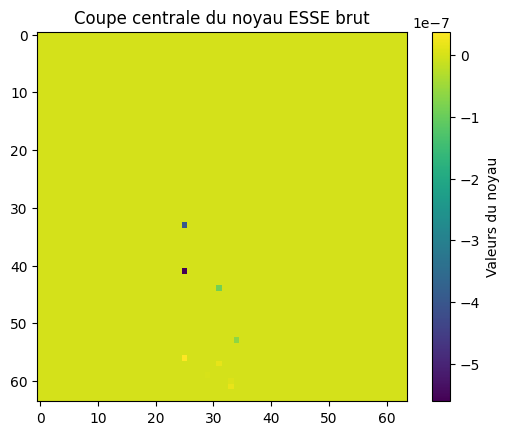

K0 shape before padding: (64, 64, 64), K1 shape before padding: (64, 64, 64), K2 shape before padding: (64, 64, 64)
Somme de K0 après padding: tensor(0.0230)
Somme de K1 après padding: tensor(-1.2605e-05)
Somme de K2 après padding: tensor(4.2212e-07)


In [698]:
esse2 = ESSEScatterModel(
    object_meta=object_meta,
    attenuation_map=attenuation_map_total,
    energy=208,
    mu_water=mu_water,
    kernels=get_new_esse_kernels(
        npy_path=npy_file_new_kernels,
        grid_size=object_meta.padded_shape
    )
)

system_matrix_ESSE = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms = [],
    object_meta = object_meta,
    proj_meta = proj_meta,
    scatter_model=esse2
)

likelihood_ESSE2 = PoissonLogLikelihood(system_matrix_ESSE, photopeak_total)
algorithm_ESSE2 = OSEM(likelihood_ESSE)

In [699]:
recon_ESSE2 = algorithm_ESSE2(n_iters=nb_iter, n_subsets=nb_subset)

Original dx: 0.44000000000000006
Tau values - Min: 0.0000, Max: 34.2151, Mean: 1.3754
Original dx: 0.44000000000000006
Tau values - Min: 0.0000, Max: 24.1698, Mean: 1.3754
Original dx: 0.44000000000000006
Tau values - Min: 0.0000, Max: 34.2151, Mean: 1.3754
Original dx: 0.44000000000000006
Tau values - Min: 0.0000, Max: 24.1698, Mean: 1.3754
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Tau values - Min: 0.0000, Max: 31.4257, Mean: 1.3753
Original dx: 0.44000000000000006
Tau values - Min: 0.0000, Max: 24.6439, Mean: 1.3754
Original dx: 0.44000000000000006
Tau values - Min: 0.0000, Max: 31.4257, Mean: 1.3753
Original dx: 0.44000000000000006
Tau values - Min: 0.0000, Max: 24.6439, Mean: 1.3753
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Original dx: 0.44000000000000006
Tau values - Mi

In [700]:
def plot_comparative_spect(recon1, recon2, vmax, label1, label2, slice_idx=None, coupe=2):
    if slice_idx is None:
        slice_idx = recon1.shape[-1] // 2
    vmax = vmax if vmax is not None else max(recon1.max().item(), recon2.max().item())

    recon1_CPU = recon1.cpu().numpy() if hasattr(recon1, 'is_cuda') and recon1.is_cuda else (recon1.numpy() if hasattr(recon1, 'numpy') else recon1)
    recon2_CPU = recon2.cpu().numpy() if hasattr(recon2, 'is_cuda') and recon2.is_cuda else (recon2.numpy() if hasattr(recon2, 'numpy') else recon2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    diff = recon1_CPU - recon2_CPU
    
    # RECONSTRUCTION 1
    if coupe == 0:
        im1 = axes[0].imshow(recon1_CPU[slice_idx, :, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im2 = axes[1].imshow(recon2_CPU[slice_idx, :, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im3 = axes[2].imshow(diff[slice_idx, :, :], cmap='RdBu_r', origin='lower', vmin=-vmax/2, vmax=vmax/2)
    elif coupe == 1:
        im1 = axes[0].imshow(recon1_CPU[:, slice_idx, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im2 = axes[1].imshow(recon2_CPU[:, slice_idx, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im3 = axes[2].imshow(diff[:, slice_idx, :], cmap='RdBu_r', origin='lower', vmin=-vmax/2, vmax=vmax/2)
    else:
        im1 = axes[0].imshow(recon1_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im2 = axes[1].imshow(recon2_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
        im3 = axes[2].imshow(diff[:, :, slice_idx], cmap='RdBu_r', origin='lower', vmin=-vmax/2, vmax=vmax/2)


    axes[0].set_title(f'{label1} ({nb_iter} iter, {nb_subset} subsets)')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], label='Intensity')

    # RECONSTRUCTION 2
    
    axes[1].set_title(f'{label2} ({nb_iter} iter, {nb_subset} subsets)')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], label='Intensity')

    # DIFFÉRENCE
    
    
    axes[2].set_title(f'Différence ({label1} - {label2})')
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], label='Δ Intensity')

In [701]:
slice_idx = 68
# vmax = max(recon_no_scatter[:, :, slice_idx].max().item(), recon_no_correction[:, :, slice_idx].max().item(), recon_ESSE[:, :, slice_idx].max().item())
# vmax = 100

slice_idx_x = 71
slice_idx_y = slice_idx
slice_idx_z = 52

slice_idx_x = 61
slice_idx_y = 68
slice_idx_z = 60
vmax_x = max(recon_no_scatter[slice_idx_x, :, :].max().item(), recon_no_correction[slice_idx_x, :, :].max().item(), recon_ESSE[slice_idx_x, :, :].max().item())
vmax_y = max(recon_no_scatter[:, slice_idx_y, :].max().item(), recon_no_correction[:, slice_idx_y, :].max().item(), recon_ESSE[:, slice_idx_y, :].max().item())
vmax_z = max(recon_no_scatter[:, :, slice_idx_z].max().item(), recon_no_correction[:, :, slice_idx_z].max().item(), recon_ESSE[:, :, slice_idx_z].max().item()) 

print(f"Max values at slice {slice_idx_x} (X): no_scatter={recon_no_scatter[slice_idx_x, :, :].max().item():.3f}, no_correction={recon_no_correction[slice_idx_x, :, :].max().item():.3f}, ESSE={recon_ESSE[slice_idx_x, :, :].max().item():.3f}")
print(f"Max values at slice {slice_idx_y} (Y): no_scatter={recon_no_scatter[:, slice_idx_y, :].max().item():.3f}, no_correction={recon_no_correction[:, slice_idx_y, :].max().item():.3f}, ESSE={recon_ESSE[:, slice_idx_y, :].max().item():.3f}")
print(f"Max values at slice {slice_idx_z} (Z): no_scatter={recon_no_scatter[:, :, slice_idx_z].max().item():.3f}, no_correction={recon_no_correction[:, :, slice_idx_z].max().item():.3f}, ESSE={recon_ESSE[:, :, slice_idx_z].max().item():.3f}")

print(recon_no_scatter.shape)

Max values at slice 61 (X): no_scatter=0.844, no_correction=44.666, ESSE=44.306
Max values at slice 68 (Y): no_scatter=3503.646, no_correction=3423.056, ESSE=3432.940
Max values at slice 60 (Z): no_scatter=5063.603, no_correction=3668.650, ESSE=3668.484
torch.Size([128, 128, 128])


In [702]:
print(f"Max value in recon_no_correction: {recon_no_correction.max().item():.3f}")
print(f"Max value in recon_no_scatter: {recon_no_scatter.max().item():.3f}")
print(f"Max value in recon_ESSE: {recon_ESSE.max().item():.3f}")
print(f"Max value in recon_TEW: {recon_TEW.max().item():.3f}")

print(f"Sum of voxels in recon_no_correction: {recon_no_correction.sum().item():.2e}")
print(f"Sum of voxels in recon_no_scatter: {recon_no_scatter.sum().item():.2e}")
print(f"Sum of voxels in recon_ESSE: {recon_ESSE.sum().item():.2e}")    
print(f"Sum of voxels in recon_TEW: {recon_TEW.sum().item():.2e}")

#print la position du max recon_no_scatter dans tout le volume
max_pos_no_scatter = torch.nonzero(recon_no_scatter == recon_no_scatter.max())
print(f"Max value in recon_no_scatter is located at: {max_pos_no_scatter}")


print(f"Max value in recon_no_correction (z={slice_idx}): {recon_no_correction[:, :, slice_idx].max().item():.3f}")
print(f"Max value in recon_no_scatter (z={slice_idx}): {recon_no_scatter[:, :, slice_idx].max().item():.3f}")
print(f"Max value in recon_ESSE (z={slice_idx}): {recon_ESSE[:, :, slice_idx].max().item():.3f}")
print(f"Max value in recon_TEW (z={slice_idx}): {recon_TEW[:, :, slice_idx].max().item():.3f}")

print(f"Sum of voxels in recon_no_correction (z={slice_idx}): {recon_no_correction[:, :, slice_idx].sum().item():.2e}")
print(f"Sum of voxels in recon_no_scatter (z={slice_idx}): {recon_no_scatter[:, :, slice_idx].sum().item():.2e}")
print(f"Sum of voxels in recon_ESSE (z={slice_idx}): {recon_ESSE[:, :, slice_idx].sum().item():.2e}")    
print(f"Sum of voxels in recon_TEW (z={slice_idx}): {recon_TEW[:, :, slice_idx].sum().item():.2e}")  

Max value in recon_no_correction: 5806.259
Max value in recon_no_scatter: 7788.699
Max value in recon_ESSE: 5814.312
Max value in recon_TEW: 5857.974
Sum of voxels in recon_no_correction: 2.62e+05
Sum of voxels in recon_no_scatter: 1.74e+05
Sum of voxels in recon_ESSE: 2.61e+05
Sum of voxels in recon_TEW: 2.15e+05
Max value in recon_no_scatter is located at: tensor([[51, 69, 71]])
Max value in recon_no_correction (z=68): 1.388
Max value in recon_no_scatter (z=68): 0.003
Max value in recon_ESSE (z=68): 1.382
Max value in recon_TEW (z=68): 0.272
Sum of voxels in recon_no_correction (z=68): 8.27e+01
Sum of voxels in recon_no_scatter (z=68): 2.18e-02
Sum of voxels in recon_ESSE (z=68): 8.12e+01
Sum of voxels in recon_TEW (z=68): 2.17e+01


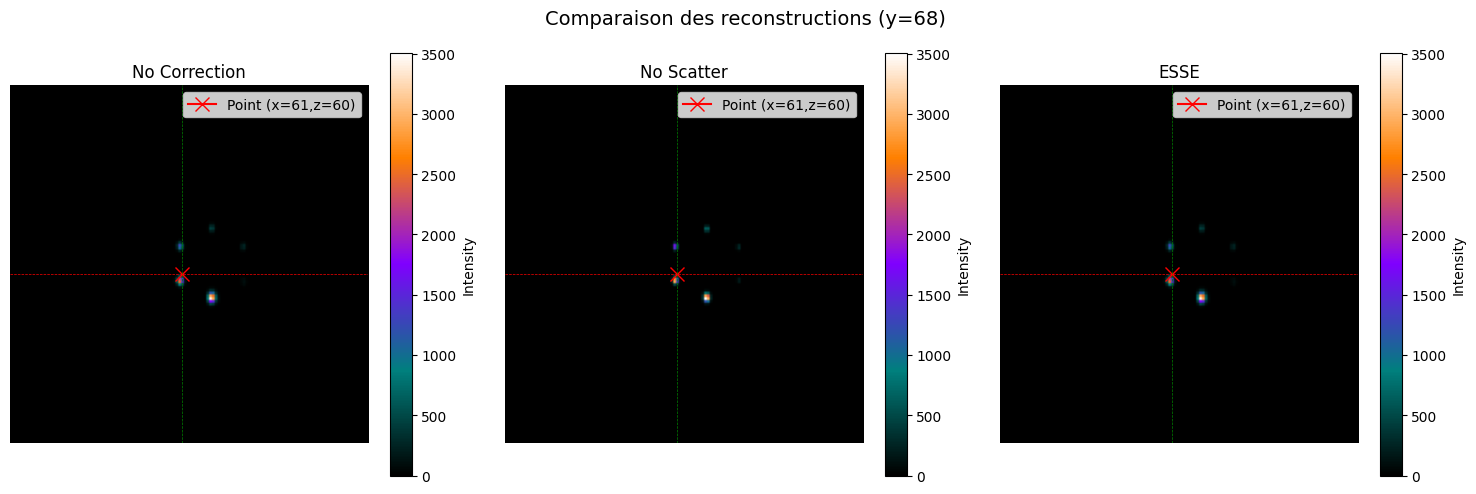

In [703]:
activer_croix = True

plt.figure(figsize=(15, 5))
titles = ['No Correction', 'No Scatter', 'ESSE']
recons = [recon_no_correction, recon_no_scatter, recon_ESSE]
plt.suptitle(f'Comparaison des reconstructions (y={slice_idx_y})', fontsize=14)
for i, (rec, title) in enumerate(zip(recons, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(title)
    plt.imshow(rec.cpu()[:, slice_idx_y, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax_y, origin='lower')
    plt.colorbar(label='Intensity')
    plt.axis('off')
    
    # plot le point de coordonnées (slice_x, slice_z) sur la coupe y avec une croix avec l'axe x en vert et l'axe z en rouge
    if activer_croix:
        plt.plot([slice_idx_x], [slice_idx_z], marker='x', color='red', markersize=10, label=f'Point (x={slice_idx_x},z={slice_idx_z})')
        plt.axhline(y=slice_idx_z, color='red', linestyle='--', linewidth=0.5)
        plt.axvline(x=slice_idx_x, color='green', linestyle='--', linewidth=0.5)
        plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


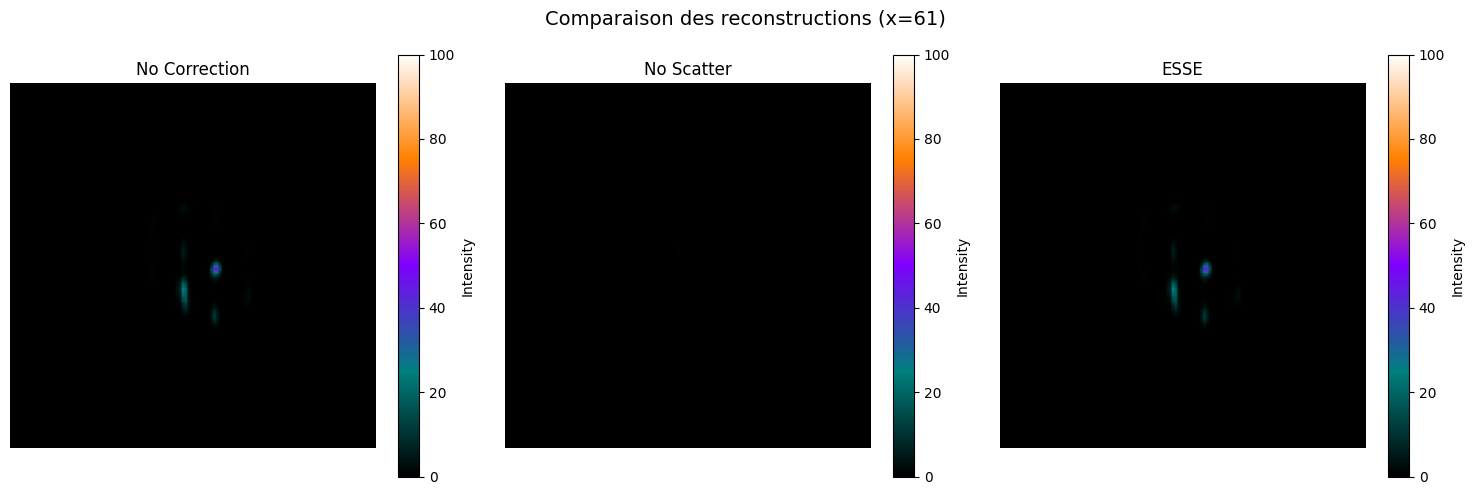

In [704]:
vmax_x = 100
plt.figure(figsize=(15, 5))
plt.suptitle(f'Comparaison des reconstructions (x={slice_idx_x})', fontsize=14)
titles = ['No Correction', 'No Scatter', 'ESSE']
recons = [recon_no_correction, recon_no_scatter, recon_ESSE]
for i, (rec, title) in enumerate(zip(recons, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(title)
    plt.imshow(rec.cpu()[slice_idx_x, :, :], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax_x, origin='lower')
    plt.colorbar(label='Intensity')
    plt.axis('off')
plt.tight_layout()
plt.show()

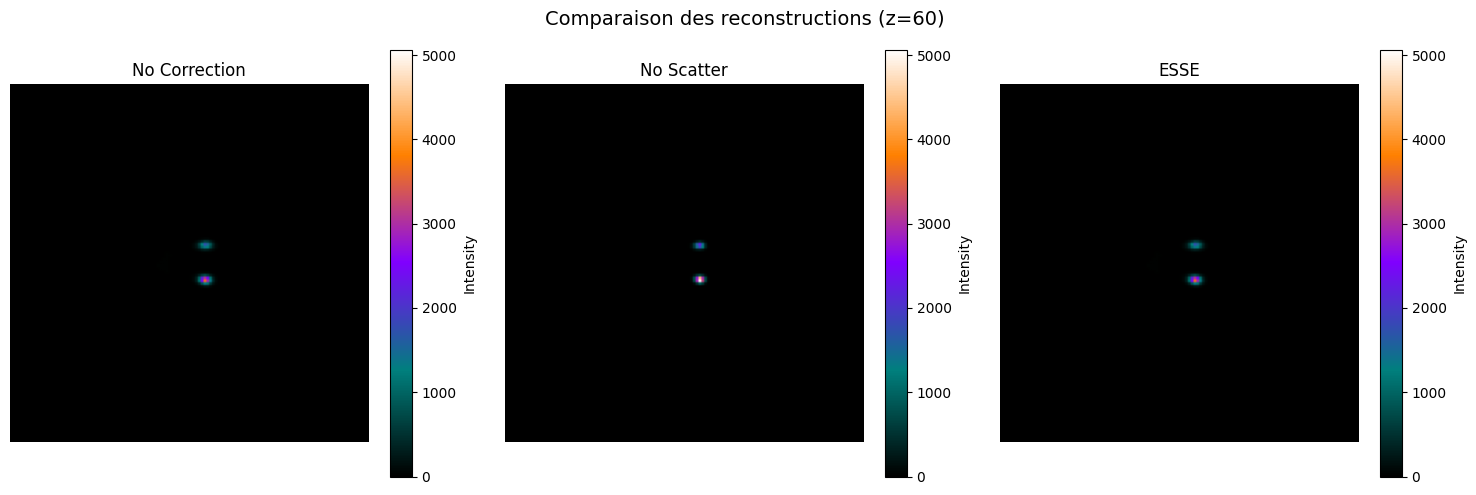

In [705]:
slice_idx_z = 60
vmax_z = max(recon_no_scatter[:, :, slice_idx_z].max().item(), recon_no_correction[:, :, slice_idx_z].max().item(), recon_ESSE[:, :, slice_idx_z].max().item())

plt.figure(figsize=(15, 5))
plt.suptitle(f'Comparaison des reconstructions (z={slice_idx_z})', fontsize=14)

titles = ['No Correction', 'No Scatter', 'ESSE']
recons = [recon_no_correction, recon_no_scatter, recon_ESSE]

for i, (rec, title) in enumerate(zip(recons, titles)):
    plt.subplot(1, 3, i + 1)
    plt.title(title)
    plt.imshow(rec.cpu()[:, :, slice_idx_z], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax_z, origin='lower')
    plt.colorbar(label='Intensity')
    plt.axis('off')

plt.tight_layout()
plt.show()

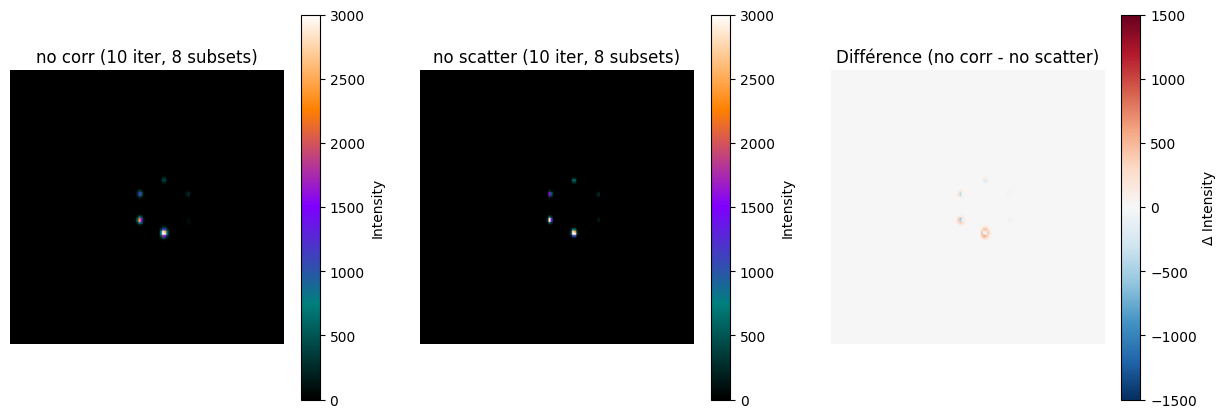

In [706]:
plot_comparative_spect(recon_no_correction, recon_no_scatter, 3000, "no corr", "no scatter", slice_idx=slice_idx_y, coupe=1)

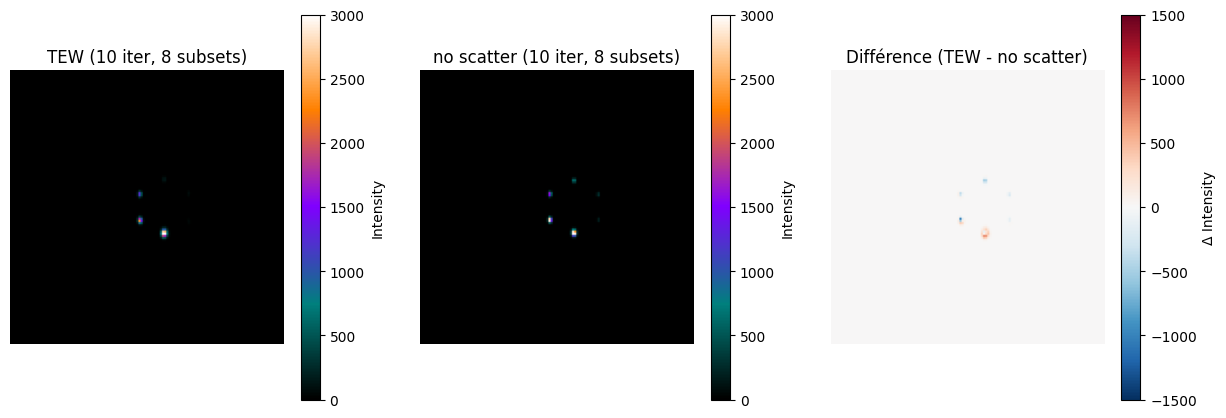

In [707]:
plot_comparative_spect(recon_TEW, recon_no_scatter, 3000, "TEW", "no scatter", slice_idx=slice_idx_y, coupe=1)

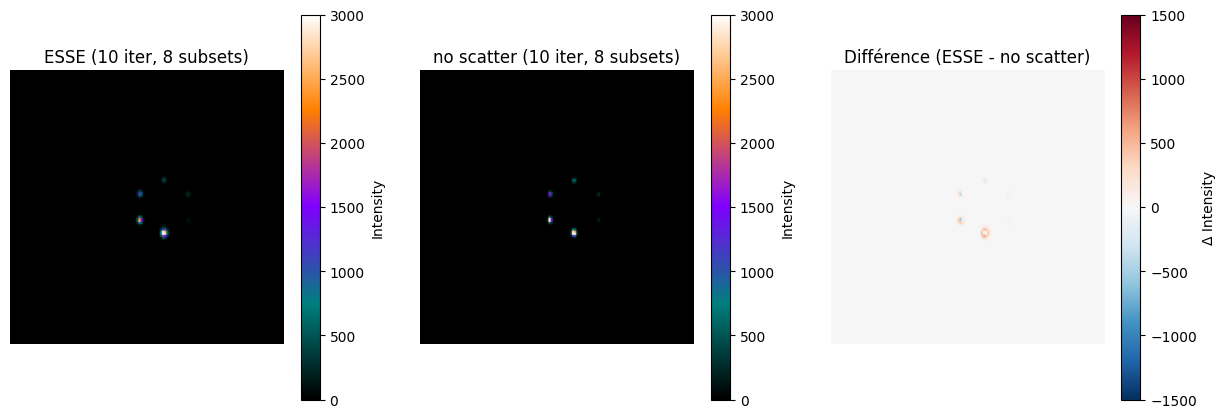

In [708]:
plot_comparative_spect(recon_ESSE, recon_no_scatter, 3000, "ESSE", "no scatter", slice_idx=slice_idx_y, coupe=1)

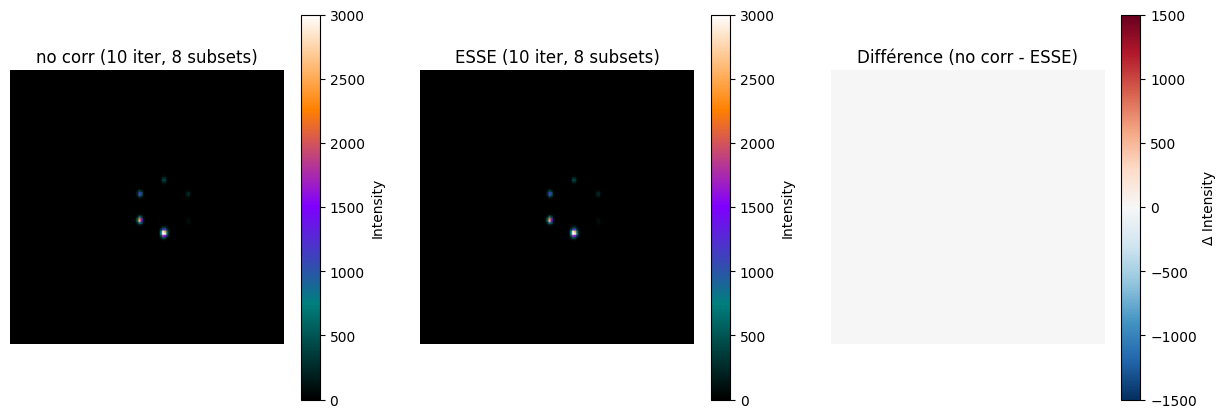

In [709]:
plot_comparative_spect(recon_no_correction, recon_ESSE, 3000, "no corr", "ESSE", slice_idx=slice_idx_y, coupe=1)

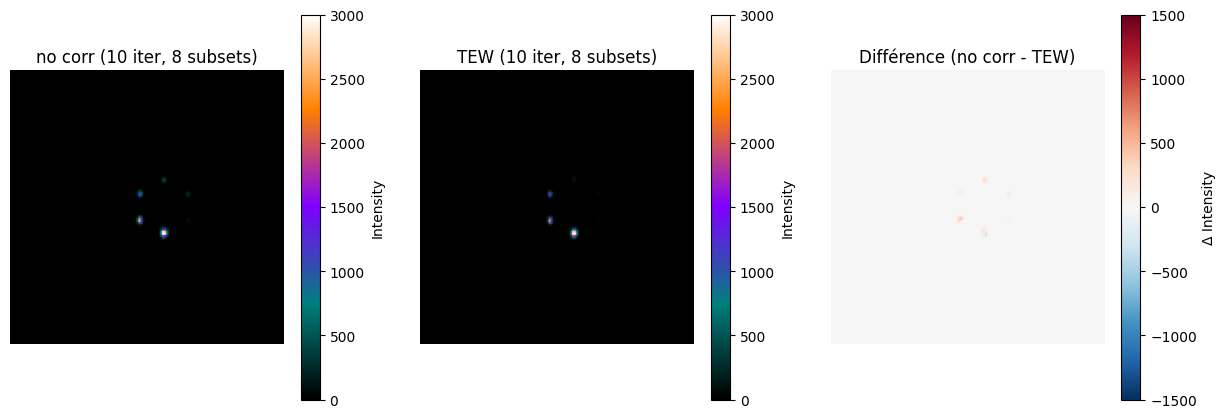

In [710]:
plot_comparative_spect(recon_no_correction, recon_TEW, 3000, "no corr", "TEW", slice_idx=slice_idx_y, coupe=1)

Résultats

In [711]:
from skimage.metrics import mean_squared_error, normalized_root_mse, peak_signal_noise_ratio, structural_similarity
import pandas as pd

def get_stats(image_tensor, reference_tensor):
    # Passage en numpy CPU
    img = image_tensor.detach().cpu().numpy()
    ref = reference_tensor.detach().cpu().numpy()
    
    # Définition de la plage dynamique (essentielle pour PSNR et SSIM)
    data_range = ref.max() - ref.min()
    
    mse = mean_squared_error(ref, img)
    nrmse = normalized_root_mse(ref, img)
    psnr = peak_signal_noise_ratio(ref, img, data_range=data_range)
    # SSIM sur volume 3D (peut être lent selon la taille de la matrice)
    # ssim = structural_similarity(ref, img, data_range=data_range)
    bias = ((np.sum(img) - np.sum(ref)) / np.sum(ref)) * 100
    
    return [mse, nrmse, psnr, bias]

# Calcul des métriques
metrics_no_corr = get_stats(recon_no_correction, recon_no_scatter)
metrics_esse = get_stats(recon_ESSE, recon_no_scatter)
metrics_tew = get_stats(recon_TEW, recon_no_scatter)
metrics_esse2 = get_stats(recon_ESSE2, recon_no_scatter)

# Présentation des résultats
df_stats = pd.DataFrame(
    [metrics_no_corr, metrics_esse, metrics_tew, metrics_esse2],
    columns=['MSE (↓)', 'NRMSE (↓)', 'PSNR (↑)', 'Biais relatif (0%)'],
    index=['No Correction vs Reference', 'ESSE vs Reference', 'TEW vs Reference', 'ESSE2 vs Reference']
)

print(df_stats.to_string())

                              MSE (↓)  NRMSE (↓)   PSNR (↑)  Biais relatif (0%)
No Correction vs Reference  18.487188   0.290785  65.160590           50.734924
ESSE vs Reference           18.486989   0.290783  65.160637           50.492714
TEW vs Reference            16.658029   0.276025  65.613063           23.969517
ESSE2 vs Reference          18.486989   0.290783  65.160637           50.492714


In [712]:
slice_idx = 64
print(f"Stats for No Correction vs Reference (z={slice_idx}):")
stats_no_corr_slice = get_stats(recon_no_correction[:, :, slice_idx], recon_no_scatter[:, :, slice_idx])
print(f"MSE: {stats_no_corr_slice[0]:.4f}, NRMSE: {stats_no_corr_slice[1]:.4f}, PSNR: {stats_no_corr_slice[2]:.2f} dB, SSIM: {stats_no_corr_slice[3]:.4f}")     
print(f"Stats for ESSE vs Reference (z={slice_idx}):")
stats_esse_slice = get_stats(recon_ESSE[:, :, slice_idx], recon_no_scatter[:, :, slice_idx])
print(f"MSE: {stats_esse_slice[0]:.4f}, NRMSE: {stats_esse_slice[1]:.4f}, PSNR: {stats_esse_slice[2]:.2f} dB, SSIM: {stats_esse_slice[3]:.4f}") 


Stats for No Correction vs Reference (z=64):
MSE: 0.0035, NRMSE: 3947.6019, PSNR: -34.66 dB, SSIM: 1178513.0000
Stats for ESSE vs Reference (z=64):
MSE: 0.0035, NRMSE: 3943.2942, PSNR: -34.65 dB, SSIM: 1163232.7500


In [713]:
# davantage de tests statistiques, comme les tests entre les méthodes de correction et par rapport à l'original
metrics_nocor_esse = get_stats(recon_no_correction, recon_ESSE)
print(f"Comparaison No Correction vs ESSE - MSE: {metrics_nocor_esse[0]:.4f}, NRMSE: {metrics_nocor_esse[1]:.4f}, PSNR: {metrics_nocor_esse[2]:.2f} dB, SSIM: {metrics_nocor_esse[3]:.4f}") 
metrics_tew_esse = get_stats(recon_TEW, recon_ESSE)
print(f"Comparaison TEW vs ESSE - MSE: {metrics_tew_esse[0]:.4f}, NRMSE: {metrics_tew_esse[1]:.4f}, PSNR: {metrics_tew_esse[2]} dB, SSIM: {metrics_tew_esse[3]:.4f}")     
metrics_nocor_tew = get_stats(recon_no_correction, recon_TEW)
print(f"Comparaison No Correction vs TEW - MSE: {metrics_nocor_tew[0]:.4f}, NRMSE: {metrics_nocor_tew[1]:.4f}, PSNR: {metrics_nocor_tew[2]:.2f} dB, SSIM: {metrics_nocor_tew[3]:.4f}")  


Comparaison No Correction vs ESSE - MSE: 0.0011, NRMSE: 0.0025, PSNR: 104.83 dB, SSIM: 0.1609
Comparaison TEW vs ESSE - MSE: 2.8947, NRMSE: 0.1262, PSNR: 70.67390488184286 dB, SSIM: -17.6242
Comparaison No Correction vs TEW - MSE: 2.8632, NRMSE: 0.1234, PSNR: 70.79 dB, SSIM: 21.5903


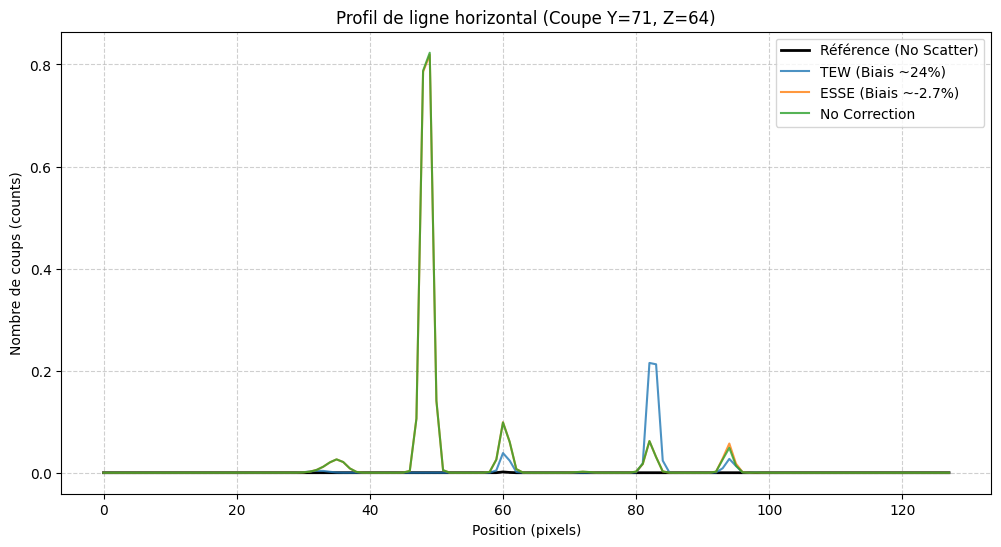

In [714]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_line_profiles(ref, recon_tew, recon_esse, recon_no_corr, title="Profil de ligne horizontal"):
    """
    Trace un profil de ligne passant par le pixel le plus brillant de la référence.
    """
    # Conversion en numpy
    ref_np = ref.detach().cpu().numpy().squeeze()
    tew_np = recon_tew.detach().cpu().numpy().squeeze()
    esse_np = recon_esse.detach().cpu().numpy().squeeze()
    no_corr_np = recon_no_corr.detach().cpu().numpy().squeeze()

    # 1. Trouver les coordonnées du pixel le plus brillant (pic de primaire)
    # Pour un volume 3D, on prend la coupe centrale ou celle du max global
    z, y, x = np.unravel_index(np.argmax(ref_np), ref_np.shape)

    z = 64  # Coupe axiale choisie (peut être ajustée)
    y = 71  # Ligne horizontale choisie (peut être ajustée)
    
    # 2. Extraire la ligne (coupe horizontale sur l'axe X)
    line_ref = ref_np[z, y, :]
    line_tew = tew_np[z, y, :]
    line_esse = esse_np[z, y, :]
    line_no_corr = no_corr_np[z, y, :]

    # 3. Visualisation
    plt.figure(figsize=(12, 6))
    plt.plot(line_ref, label='Référence (No Scatter)', color='black', linewidth=2)
    plt.plot(line_tew, label='TEW (Biais ~24%)', alpha=0.8)
    plt.plot(line_esse, label='ESSE (Biais ~-2.7%)', alpha=0.8)
    plt.plot(line_no_corr, label='No Correction', alpha=0.8)

    plt.title(f"{title} (Coupe Y={y}, Z={z})")
    plt.xlabel("Position (pixels)")
    plt.ylabel("Nombre de coups (counts)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Utilisation
plot_line_profiles(recon_no_scatter, recon_TEW, recon_ESSE, recon_no_correction)